# Imports 

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition    import TruncatedSVD
from sklearn.model_selection  import train_test_split
from sklearn.metrics          import mean_squared_error, mean_absolute_error
import warnings, os

warnings.filterwarnings('ignore')
np.random.seed(42)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 14, 'axes.labelsize': 12})

def report_memory(df, label=''):
    mb = df.memory_usage(deep=True).sum() / 1e6
    print(f'  Memory {label}: {mb:.2f} MB  ({len(df):,} rows)')

print('=' * 65)
print('PRT840 – UNRR Framework | Amazon Product Reviews Dataset')
print('=' * 65)

PRT840 – UNRR Framework | Amazon Product Reviews Dataset


# Load Dataset

In [19]:
print('[1] Loading Amazon Product Reviews dataset...')

df_raw = pd.read_csv('Amazon_Product_Reviews.csv', low_memory=False)

print(f'  Raw shape    : {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns')
print(f'  Columns      : {list(df_raw.columns)}')
print(f'\n  Key field overview:')
print(f'    Unique users    : {df_raw["reviews.username"].nunique():,}')
print(f'    Unique products : {df_raw["asins"].nunique():,}')
print(f'    Rating range    : {df_raw["reviews.rating"].min()} - {df_raw["reviews.rating"].max()}')
print(f'\n  Missing values in key columns:')
print(df_raw[['reviews.username','asins','reviews.rating',
              'reviews.date','reviews.text','reviews.numHelpful']].isnull().sum())
print(f'\n  Sample rows:')
print(df_raw[['reviews.username','asins','reviews.rating',
              'reviews.numHelpful','reviews.doRecommend','reviews.date']].head())

[1] Loading Amazon Product Reviews dataset...
  Raw shape    : 1,597 rows x 27 columns
  Columns      : ['id', 'asins', 'brand', 'categories', 'colors', 'dateAdded', 'dateUpdated', 'dimension', 'ean', 'keys', 'manufacturer', 'manufacturerNumber', 'name', 'prices', 'reviews.date', 'reviews.doRecommend', 'reviews.numHelpful', 'reviews.rating', 'reviews.sourceURLs', 'reviews.text', 'reviews.title', 'reviews.userCity', 'reviews.userProvince', 'reviews.username', 'sizes', 'upc', 'weight']

  Key field overview:
    Unique users    : 949
    Unique products : 54
    Rating range    : 1.0 - 5.0

  Missing values in key columns:
reviews.username       17
asins                   0
reviews.rating        420
reviews.date          380
reviews.text            0
reviews.numHelpful    697
dtype: int64

  Sample rows:
     reviews.username       asins  reviews.rating  reviews.numHelpful  \
0          Cristina M  B00QJDU3KY             5.0               139.0   
1               Ricky  B00QJDU3KY       

# Preprocessing and Mapping

In [20]:
print('[2] Preprocessing & Column Mapping...')
 
# Select and rename relevant columns to UNRR-standard names
df = df_raw[[
    'reviews.username', 'asins', 'name',
    'reviews.rating', 'reviews.numHelpful',
    'reviews.doRecommend', 'reviews.date', 'reviews.text'
]].copy()
 
df.rename(columns={
    'reviews.username'   : 'customer_id',
    'asins'              : 'product_id',
    'name'               : 'product_name',
    'reviews.rating'     : 'star_rating',
    'reviews.numHelpful' : 'helpful_votes',
    'reviews.doRecommend': 'do_recommend',
    'reviews.date'       : 'review_date',
    'reviews.text'       : 'review_body',
}, inplace=True)
 
# Drop rows missing core fields 
before = len(df)
df.dropna(subset=['product_id', 'star_rating'], inplace=True)
print(f'  Dropped missing core fields : {before - len(df):,} rows')
 
# Fix: assign anonymous IDs to missing usernames
# Uses boolean mask — avoids TypeError from fillna + Index object
missing_mask = df['customer_id'].isna()
df.loc[missing_mask, 'customer_id'] = [
    f'anonymous_{i}' for i in df.index[missing_mask]
]
print(f'  Anonymous IDs assigned      : {missing_mask.sum():,} users')
print(f'  Remaining null customer_ids : {df["customer_id"].isna().sum()}')
 
# Type coercion 
df['star_rating']   = pd.to_numeric(df['star_rating'],   errors='coerce')
df['helpful_votes'] = pd.to_numeric(df['helpful_votes'], errors='coerce').fillna(0).astype(int)
df['review_date']   = pd.to_datetime(df['review_date'],  errors='coerce')
 
# Keep only valid ratings 1–5 
df = df[df['star_rating'].between(1, 5)]
df['star_rating'] = df['star_rating'].astype(int)
print(f'  Rows with valid rating (1-5): {len(df):,}')
 
# Derived features 
df['review_year']   = df['review_date'].dt.year
df['review_length'] = df['review_body'].fillna('').apply(len)
 
# do_recommend as verified_purchase proxy
df['verified_purchase'] = df['do_recommend'].map(
    {True: 'Y', False: 'N'}
).fillna('N')
 
# User & item activity counts 
user_activity = (df.groupby('customer_id')['product_id']
                 .count().rename('user_review_count'))
item_activity = (df.groupby('product_id')['customer_id']
                 .count().rename('item_review_count'))
df = df.join(user_activity, on='customer_id').join(item_activity, on='product_id')
 
# Label all rows as original clean data 
df['noise_type']   = 'original'
df['attack_label'] = 0
 
# Final check 
report_memory(df, 'after preprocessing')
print(f'  Unique users    : {df["customer_id"].nunique():,}')
print(f'  Unique products : {df["product_id"].nunique():,}')
print()
print('  ✅ All columns confirmed:')
for col in ['customer_id','product_id','star_rating','review_date',
            'review_length','verified_purchase','noise_type','attack_label']:
    nulls = df[col].isna().sum()
    print(f'    {col:25s} | nulls: {nulls}')
print()
print(df[['customer_id','product_id','star_rating','review_year',
          'review_length','verified_purchase','user_review_count']].head())

[2] Preprocessing & Column Mapping...
  Dropped missing core fields : 420 rows
  Anonymous IDs assigned      : 0 users
  Remaining null customer_ids : 0
  Rows with valid rating (1-5): 1,177
  Memory after preprocessing: 1.42 MB  (1,177 rows)
  Unique users    : 836
  Unique products : 54

  ✅ All columns confirmed:
    customer_id               | nulls: 0
    product_id                | nulls: 0
    star_rating               | nulls: 0
    review_date               | nulls: 327
    review_length             | nulls: 0
    verified_purchase         | nulls: 0
    noise_type                | nulls: 0
    attack_label              | nulls: 0

          customer_id  product_id  star_rating  review_year  review_length  \
0          Cristina M  B00QJDU3KY            5       2015.0           1064   
1               Ricky  B00QJDU3KY            5       2015.0           1424   
2       Tedd Gardiner  B00QJDU3KY            4       2015.0            182   
3              Dougal  B00QJDU3KY      

# Descriptive Statistics

[3] Descriptive Statistics
       star_rating  review_length  helpful_votes  user_review_count  \
count      1177.00        1177.00        1177.00            1177.00   
mean          4.36         735.96          63.91               4.74   
std           1.02        1284.39         175.99               8.07   
min           1.00           3.00           0.00               1.00   
25%           4.00         115.00           0.00               1.00   
50%           5.00         280.00           0.00               1.00   
75%           5.00        1527.00           8.00               4.00   
max           5.00       19739.00         997.00              38.00   

       item_review_count  
count            1177.00  
mean              264.92  
std               256.68  
min                 3.00  
25%                18.00  
50%                77.00  
75%               542.00  
max               542.00  


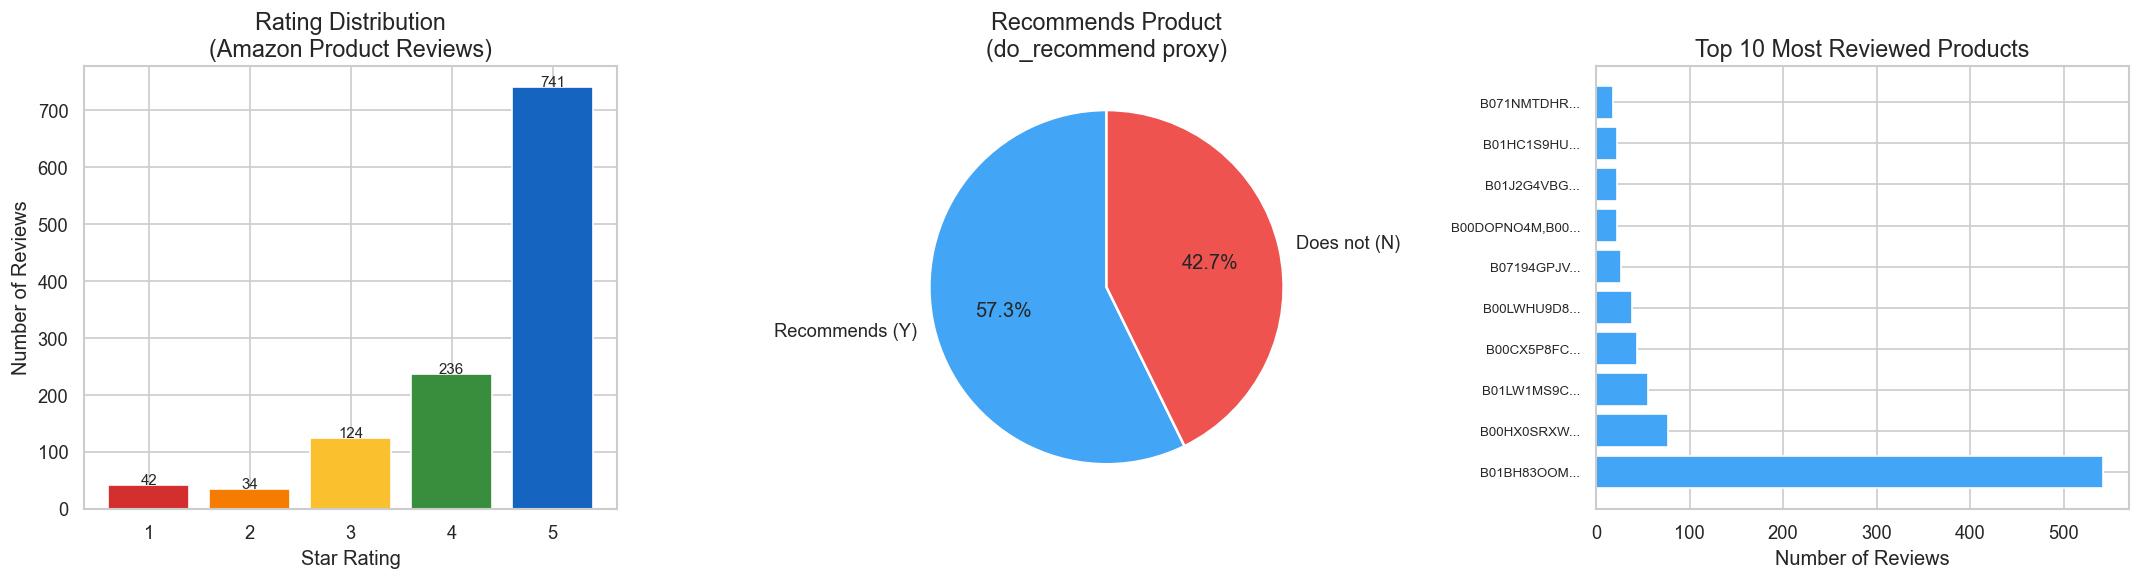

  Saved: fig1_descriptive_stats.png


In [21]:
print('[3] Descriptive Statistics')

print(df[['star_rating','review_length','helpful_votes',
          'user_review_count','item_review_count']].describe().round(2))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Rating distribution
rc = df['star_rating'].value_counts().sort_index()
axes[0].bar(rc.index, rc.values,
            color=['#d32f2f','#f57c00','#fbc02d','#388e3c','#1565c0'])
axes[0].set_title('Rating Distribution\n(Amazon Product Reviews)')
axes[0].set_xlabel('Star Rating'); axes[0].set_ylabel('Number of Reviews')
for x, y in zip(rc.index, rc.values):
    axes[0].text(x, y + 1, f'{y:,}', ha='center', fontsize=9)

# Do-recommend distribution
vp = df['verified_purchase'].value_counts()
axes[1].pie(vp.values, labels=['Recommends (Y)','Does not (N)'],
            autopct='%1.1f%%', colors=['#42a5f5','#ef5350'],
            startangle=90, wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[1].set_title('Recommends Product\n(do_recommend proxy)')

# Top 10 most reviewed products
top_products = (df.groupby('product_id')['star_rating']
                .count().sort_values(ascending=False).head(10))
axes[2].barh(range(len(top_products)), top_products.values,
             color='#42a5f5', edgecolor='white')
axes[2].set_yticks(range(len(top_products)))
axes[2].set_yticklabels([p[:14]+'...' for p in top_products.index], fontsize=8)
axes[2].set_title('Top 10 Most Reviewed Products')
axes[2].set_xlabel('Number of Reviews')

plt.tight_layout()
plt.savefig('fig1_descriptive_stats.png', bbox_inches='tight')
plt.show()
print('  Saved: fig1_descriptive_stats.png')


# Natural Noise Analaysis

[4] Natural Noise Analysis
  High-variance users (std >= 0.71): 10
  Low-signal reviews (< 50 chars): 35 (3.0%)
  Reviews with 0 helpful votes: 781 (66.4%)


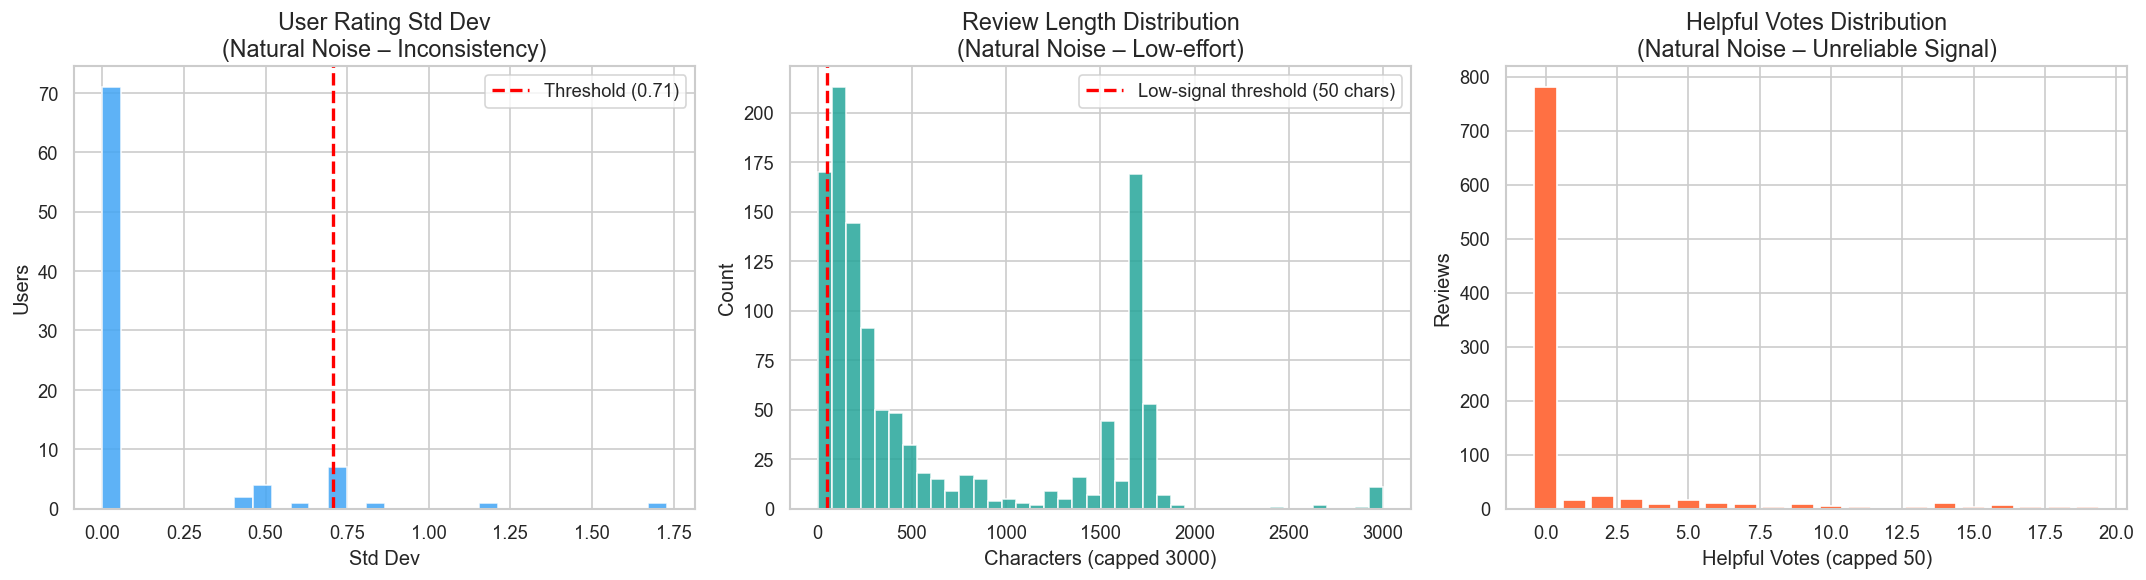

  Saved: fig2_natural_noise_analysis.png


In [22]:
print('[4] Natural Noise Analysis')

# 4.1 User rating variance
user_rating_stats = df.groupby('customer_id')['star_rating'].agg(['mean','std','count'])
user_rating_stats.columns = ['mean_rating','std_rating','review_count']
user_rating_stats = user_rating_stats[user_rating_stats['review_count'] >= 2].dropna()

HIGH_VAR_THRESHOLD = user_rating_stats['std_rating'].quantile(0.90)
high_var_users = user_rating_stats[user_rating_stats['std_rating'] >= HIGH_VAR_THRESHOLD]
print(f'  High-variance users (std >= {HIGH_VAR_THRESHOLD:.2f}): {len(high_var_users):,}')

# 4.2 Short reviews
VERY_SHORT = 50  # higher threshold — product reviews tend to be longer
short_reviews = df[df['review_length'] < VERY_SHORT]
print(f'  Low-signal reviews (< {VERY_SHORT} chars): {len(short_reviews):,} ({len(short_reviews)/len(df)*100:.1f}%)')

# 4.3 Zero helpful votes despite existing reviews
zero_helpful = df[df['helpful_votes'] == 0]
print(f'  Reviews with 0 helpful votes: {len(zero_helpful):,} ({len(zero_helpful)/len(df)*100:.1f}%)')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(user_rating_stats['std_rating'].dropna(), bins=30,
             color='#42a5f5', edgecolor='white', alpha=0.85)
axes[0].axvline(HIGH_VAR_THRESHOLD, color='red', linestyle='--', linewidth=2,
                label=f'Threshold ({HIGH_VAR_THRESHOLD:.2f})')
axes[0].set_title('User Rating Std Dev\n(Natural Noise – Inconsistency)')
axes[0].set_xlabel('Std Dev'); axes[0].set_ylabel('Users'); axes[0].legend()

axes[1].hist(df['review_length'].clip(upper=3000), bins=40,
             color='#26a69a', edgecolor='white', alpha=0.85)
axes[1].axvline(VERY_SHORT, color='red', linestyle='--', linewidth=2,
                label=f'Low-signal threshold ({VERY_SHORT} chars)')
axes[1].set_title('Review Length Distribution\n(Natural Noise – Low-effort)')
axes[1].set_xlabel('Characters (capped 3000)'); axes[1].set_ylabel('Count'); axes[1].legend()

helpful_dist = df['helpful_votes'].clip(upper=50).value_counts().sort_index().head(20)
axes[2].bar(helpful_dist.index, helpful_dist.values, color='#ff7043', edgecolor='white')
axes[2].set_title('Helpful Votes Distribution\n(Natural Noise – Unreliable Signal)')
axes[2].set_xlabel('Helpful Votes (capped 50)'); axes[2].set_ylabel('Reviews')

plt.tight_layout()
plt.savefig('fig2_natural_noise_analysis.png', bbox_inches='tight')
plt.show()
print('  Saved: fig2_natural_noise_analysis.png')

# Synthetic Shilling Attack Injection

[5] Synthetic Shilling Attack Injection
  Dataset size       : 1,177
  Fake profiles/type : 20
  Filler items/user  : 5
  Target items       : ['B01BH83OOM', 'B00HX0SRXW', 'B01LW1MS9C']
  Global mean rating : 4.36
  Injecting Random Attack...
    Rows: 120
  Injecting Average Attack...
    Rows: 120
  Injecting Bandwagon Attack...
    Rows: 120

  Total injected : 360 | Combined: 1,537 (23.4%)
  Exported: amazon_product_reviews_with_attacks.csv  (1.01 MB)


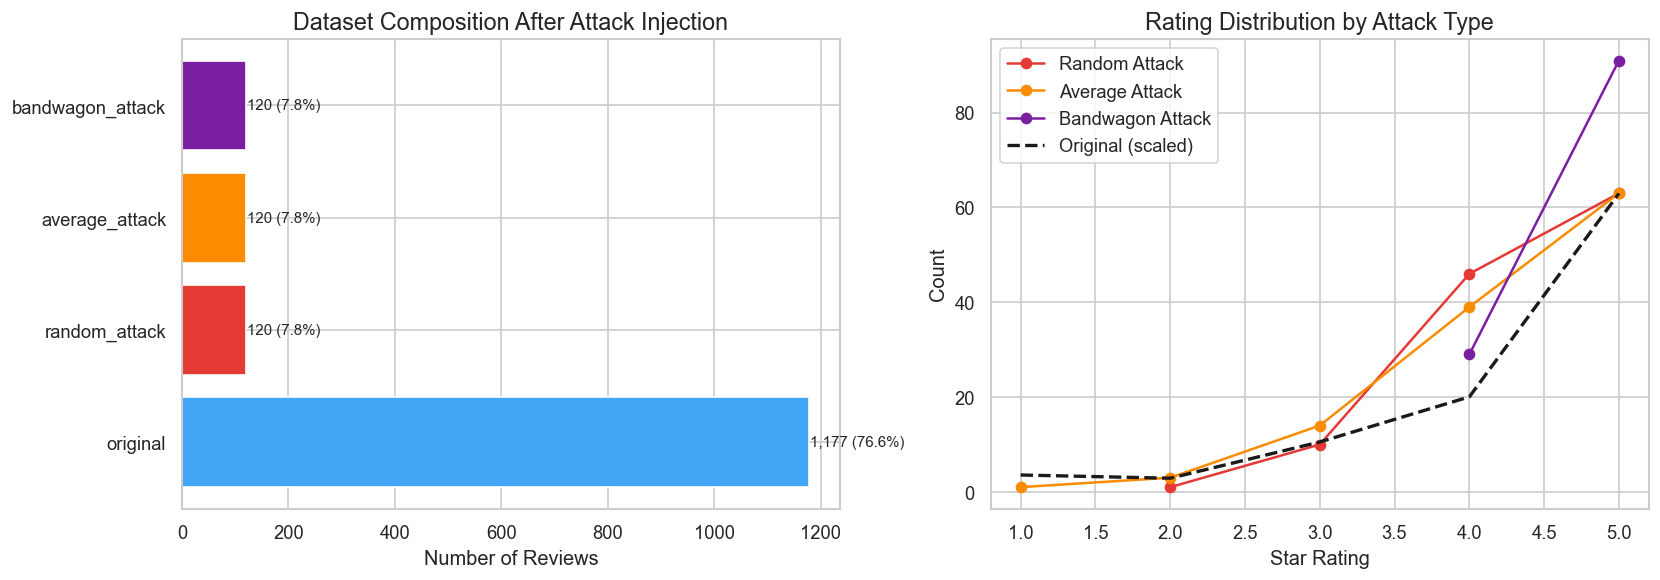

  Saved: fig3_attack_injection.png


In [23]:
print('[5] Synthetic Shilling Attack Injection')

ATTACK_SIZE_PCT   = 0.05   # 5% — calibrated for small dataset
FILLER_SIZE       = 5      # smaller filler — only 54 products total
N_TARGET_ITEMS    = 3      # top 3 most-reviewed products

N_ORIGINAL        = len(df)
N_ATTACK_PROFILES = max(20, int(N_ORIGINAL * ATTACK_SIZE_PCT / (FILLER_SIZE + 1)))

item_counts   = df.groupby('product_id').size().sort_values(ascending=False)
target_items  = item_counts.head(N_TARGET_ITEMS).index.tolist()
all_items     = df['product_id'].unique().tolist()
global_mean   = float(df['star_rating'].mean())
item_means    = df.groupby('product_id')['star_rating'].mean().astype(float)
popular_items = item_counts[~item_counts.index.isin(target_items)].head(10).index.tolist()
ref_date      = df['review_date'].dropna().max()

print(f'  Dataset size       : {N_ORIGINAL:,}')
print(f'  Fake profiles/type : {N_ATTACK_PROFILES:,}')
print(f'  Filler items/user  : {FILLER_SIZE}')
print(f'  Target items       : {target_items}')
print(f'  Global mean rating : {global_mean:.2f}')

fake_id_counter = [0]

def make_fake_review(customer_id, product_id, star_rating, noise_type):
    fake_id_counter[0] += 1
    return {
        'customer_id'      : customer_id,
        'product_id'       : product_id,
        'product_name'     : 'Unknown',
        'star_rating'      : int(star_rating),
        'helpful_votes'    : 0,
        'do_recommend'     : False,
        'review_date'      : ref_date,
        'review_body'      : 'Great product.',
        'review_year'      : ref_date.year if pd.notna(ref_date) else 2017,
        'review_length'    : len('Great product.'),
        'verified_purchase': 'N',
        'user_review_count': FILLER_SIZE + 1,
        'item_review_count': 0,
        'noise_type'       : noise_type,
        'attack_label'     : 1,
    }

# Random Attack
print('  Injecting Random Attack...')
random_rows = []
for i in range(N_ATTACK_PROFILES):
    uid = f'FAKE_RAND_{i:05d}'
    target = np.random.choice(target_items)
    random_rows.append(make_fake_review(uid, target, 5, 'random_attack'))
    fillers = np.random.choice([x for x in all_items if x != target],
                                size=min(FILLER_SIZE, len(all_items)-1), replace=False)
    for fi in fillers:
        r = int(np.clip(np.round(np.random.normal(global_mean, 1.0)), 1, 5))
        random_rows.append(make_fake_review(uid, fi, r, 'random_attack'))
df_random = pd.DataFrame(random_rows)
print(f'    Rows: {len(df_random):,}')

# Average Attack
print('  Injecting Average Attack...')
average_rows = []
for i in range(N_ATTACK_PROFILES):
    uid = f'FAKE_AVG_{i:05d}'
    target = np.random.choice(target_items)
    average_rows.append(make_fake_review(uid, target, 5, 'average_attack'))
    fillers = np.random.choice([x for x in all_items if x != target],
                                size=min(FILLER_SIZE, len(all_items)-1), replace=False)
    for fi in fillers:
        mu = float(item_means.get(fi, global_mean))
        r  = int(np.clip(np.round(np.random.normal(mu, 0.5)), 1, 5))
        average_rows.append(make_fake_review(uid, fi, r, 'average_attack'))
df_average = pd.DataFrame(average_rows)
print(f'    Rows: {len(df_average):,}')

# Bandwagon Attack
print('  Injecting Bandwagon Attack...')
bandwagon_rows = []
for i in range(N_ATTACK_PROFILES):
    uid = f'FAKE_BAND_{i:05d}'
    target = np.random.choice(target_items)
    bandwagon_rows.append(make_fake_review(uid, target, 5, 'bandwagon_attack'))
    bw = np.random.choice(popular_items, size=min(FILLER_SIZE, len(popular_items)), replace=False)
    for bi in bw:
        r = int(np.random.choice([4, 5], p=[0.3, 0.7]))
        bandwagon_rows.append(make_fake_review(uid, bi, r, 'bandwagon_attack'))
df_bandwagon = pd.DataFrame(bandwagon_rows)
print(f'    Rows: {len(df_bandwagon):,}')

# Merge
df_injected = pd.concat([df, df_random, df_average, df_bandwagon],
                        ignore_index=True, sort=False)
new_ic = df_injected.groupby('product_id')['customer_id'].count().rename('item_review_count_new')
df_injected = df_injected.drop(columns=['item_review_count']).join(new_ic, on='product_id')
df_injected.rename(columns={'item_review_count_new': 'item_review_count'}, inplace=True)

total_injected = len(df_random) + len(df_average) + len(df_bandwagon)
print(f'\n  Total injected : {total_injected:,} | Combined: {len(df_injected):,} ({total_injected/len(df_injected)*100:.1f}%)')

# Export
OUTPUT_CSV = 'amazon_product_reviews_with_attacks.csv'
df_injected.to_csv(OUTPUT_CSV, index=False)
file_size_mb = os.path.getsize(OUTPUT_CSV) / (1024*1024)
print(f'  Exported: {OUTPUT_CSV}  ({file_size_mb:.2f} MB)')

# Chart
colors_inj = {'original':'#42a5f5','random_attack':'#e53935',
              'average_attack':'#fb8c00','bandwagon_attack':'#7b1fa2'}
inj_sum = df_injected['noise_type'].value_counts().reset_index()
inj_sum.columns = ['noise_type','count']
inj_sum['pct'] = inj_sum['count'] / len(df_injected) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bars = axes[0].barh(inj_sum['noise_type'], inj_sum['count'],
                    color=[colors_inj.get(t,'#aaa') for t in inj_sum['noise_type']],
                    edgecolor='white')
axes[0].set_title('Dataset Composition After Attack Injection')
axes[0].set_xlabel('Number of Reviews')
for bar, row in zip(bars, inj_sum.itertuples()):
    axes[0].text(bar.get_width()+2, bar.get_y()+bar.get_height()/2,
                 f'{row.count:,} ({row.pct:.1f}%)', va='center', fontsize=9)

atk_only = df_injected[df_injected['attack_label'] == 1]
for atk in ['random_attack','average_attack','bandwagon_attack']:
    sub = atk_only[atk_only['noise_type']==atk]['star_rating'].value_counts().sort_index()
    axes[1].plot(sub.index, sub.values, marker='o',
                 label=atk.replace('_',' ').title(), color=colors_inj[atk])
orig_d = df['star_rating'].value_counts().sort_index() / len(df) * (N_ATTACK_PROFILES * FILLER_SIZE)
axes[1].plot(orig_d.index, orig_d.values, 'k--', linewidth=2, label='Original (scaled)')
axes[1].set_title('Rating Distribution by Attack Type')
axes[1].set_xlabel('Star Rating'); axes[1].set_ylabel('Count'); axes[1].legend()
plt.tight_layout()
plt.savefig('fig3_attack_injection.png', bbox_inches='tight')
plt.show()
print('  Saved: fig3_attack_injection.png')


# Load and Verify Injected Dataset

In [24]:
print('[6] Loading Injected Dataset...')

df_work = pd.read_csv(OUTPUT_CSV, low_memory=False)
df_work['review_date']  = pd.to_datetime(df_work['review_date'], errors='coerce')
df_work['star_rating']  = pd.to_numeric(df_work['star_rating'],  errors='coerce')
df_work['helpful_votes']= pd.to_numeric(df_work['helpful_votes'],errors='coerce').fillna(0).astype(int)
df_work['review_length']= pd.to_numeric(df_work['review_length'],errors='coerce').fillna(0).astype(int)

report_memory(df_work, 'injected dataset')
print(f'  Shape: {df_work.shape[0]:,} rows x {df_work.shape[1]} columns')
print(f'  Noise type counts:\n{df_work["noise_type"].value_counts()}')
print(f'  Attack label counts:\n{df_work["attack_label"].value_counts()}')
print(df_work[df_work['attack_label']==1][
    ['customer_id','product_id','star_rating','noise_type','verified_purchase']
].head(5).to_string(index=False))


[6] Loading Injected Dataset...
  Memory injected dataset: 1.58 MB  (1,537 rows)
  Shape: 1,537 rows x 15 columns
  Noise type counts:
noise_type
original            1177
random_attack        120
average_attack       120
bandwagon_attack     120
Name: count, dtype: int64
  Attack label counts:
attack_label
0    1177
1     360
Name: count, dtype: int64
    customer_id product_id  star_rating    noise_type verified_purchase
FAKE_RAND_00000 B01LW1MS9C            5 random_attack                 N
FAKE_RAND_00000 B010EK1GOE            5 random_attack                 N
FAKE_RAND_00000 B01HC1S9HU            4 random_attack                 N
FAKE_RAND_00000 B01E9AHU8Q            3 random_attack                 N
FAKE_RAND_00000 B00VKM5NFY            4 random_attack                 N


# Target Item Rating Impact

[7] Target Item Rating Impact
  Rating Shift per Target Item per Attack Type:
   product_id      attack_type  original_mean  combined_mean  rating_shift  n_injected
B01BH83OOM...    Random Attack          4.533          4.536         0.003           6
B01BH83OOM...   Average Attack          4.533          4.537         0.004           5
B01BH83OOM... Bandwagon Attack          4.533          4.538         0.005           6
B00HX0SRXW...    Random Attack          4.013          4.126         0.113          10
B00HX0SRXW...   Average Attack          4.013          4.093         0.080           9
B00HX0SRXW... Bandwagon Attack          4.013          4.062         0.049           4
B01LW1MS9C...    Random Attack          4.679          4.710         0.031           6
B01LW1MS9C...   Average Attack          4.679          4.719         0.040           8
B01LW1MS9C... Bandwagon Attack          4.679          4.727         0.049          10


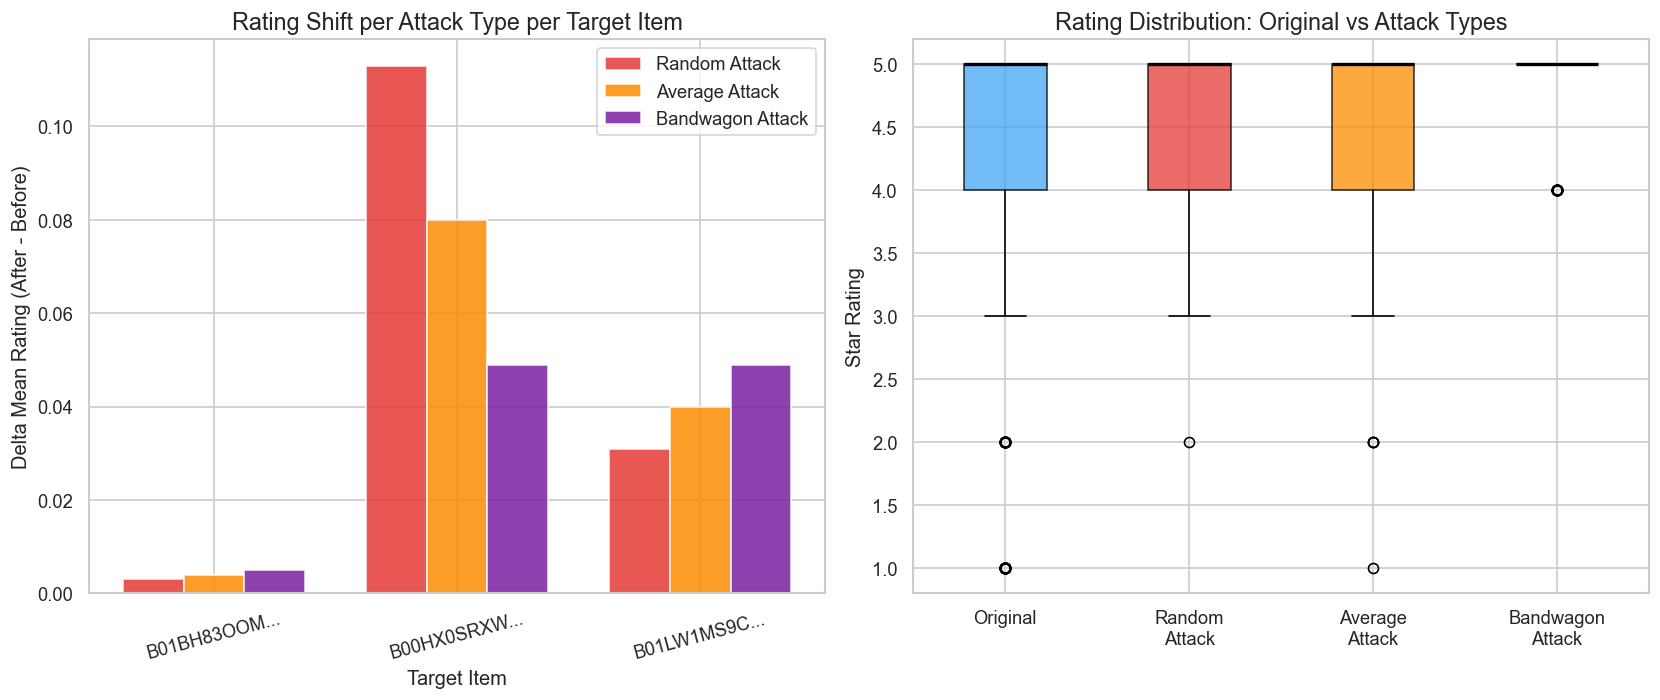

  Saved: fig4_target_item_impact.png


In [25]:
print('[7] Target Item Rating Impact')

impact_rows = []
for item in target_items:
    orig_mean = float(df[df['product_id']==item]['star_rating'].mean())
    for atk in ['random_attack','average_attack','bandwagon_attack']:
        atk_r = df_work[(df_work['product_id']==item)&(df_work['noise_type']==atk)]['star_rating'].dropna()
        combined_mean = float(pd.concat([df[df['product_id']==item]['star_rating'], atk_r]).mean())
        impact_rows.append({
            'product_id'   : item[:16]+'...',
            'attack_type'  : atk.replace('_',' ').title(),
            'original_mean': round(orig_mean, 3),
            'combined_mean': round(combined_mean, 3),
            'rating_shift' : round(combined_mean - orig_mean, 3),
            'n_injected'   : len(atk_r),
        })

impact_df = pd.DataFrame(impact_rows)
print('  Rating Shift per Target Item per Attack Type:')
print(impact_df.to_string(index=False))

atk_color = {'Random Attack':'#e53935','Average Attack':'#fb8c00','Bandwagon Attack':'#7b1fa2'}
x_pos = np.arange(len(target_items)); width = 0.25; offsets = [-width,0,width]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for atk, offset in zip(['Random Attack','Average Attack','Bandwagon Attack'], offsets):
    vals = [impact_df[(impact_df['attack_type']==atk)&
                      (impact_df['product_id']==t[:16]+'...')]['rating_shift'].values[0]
            for t in target_items]
    axes[0].bar(x_pos+offset, vals, width, label=atk,
                color=atk_color[atk], edgecolor='white', alpha=0.85)
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_title('Rating Shift per Attack Type per Target Item')
axes[0].set_xlabel('Target Item')
axes[0].set_ylabel('Delta Mean Rating (After - Before)')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels([t[:14]+'...' for t in target_items], rotation=15)
axes[0].legend()

plot_data, plot_labels = [], []
for nt in ['original','random_attack','average_attack','bandwagon_attack']:
    sub = df_work[df_work['noise_type']==nt]['star_rating'].dropna()
    plot_data.append(sub.astype(float).values)
    plot_labels.append(nt.replace('_','\n').title())
bp = axes[1].boxplot(plot_data, labels=plot_labels, patch_artist=True,
                     medianprops={'color':'black','linewidth':2})
for patch, color in zip(bp['boxes'],['#42a5f5','#e53935','#fb8c00','#7b1fa2']):
    patch.set_facecolor(color); patch.set_alpha(0.75)
axes[1].set_title('Rating Distribution: Original vs Attack Types')
axes[1].set_ylabel('Star Rating')
plt.tight_layout()
plt.savefig('fig4_target_item_impact.png', bbox_inches='tight')
plt.show()
print('  Saved: fig4_target_item_impact.png')


## Before vs After Rating Counts per Target Item

[8] Before vs After Rating Counts


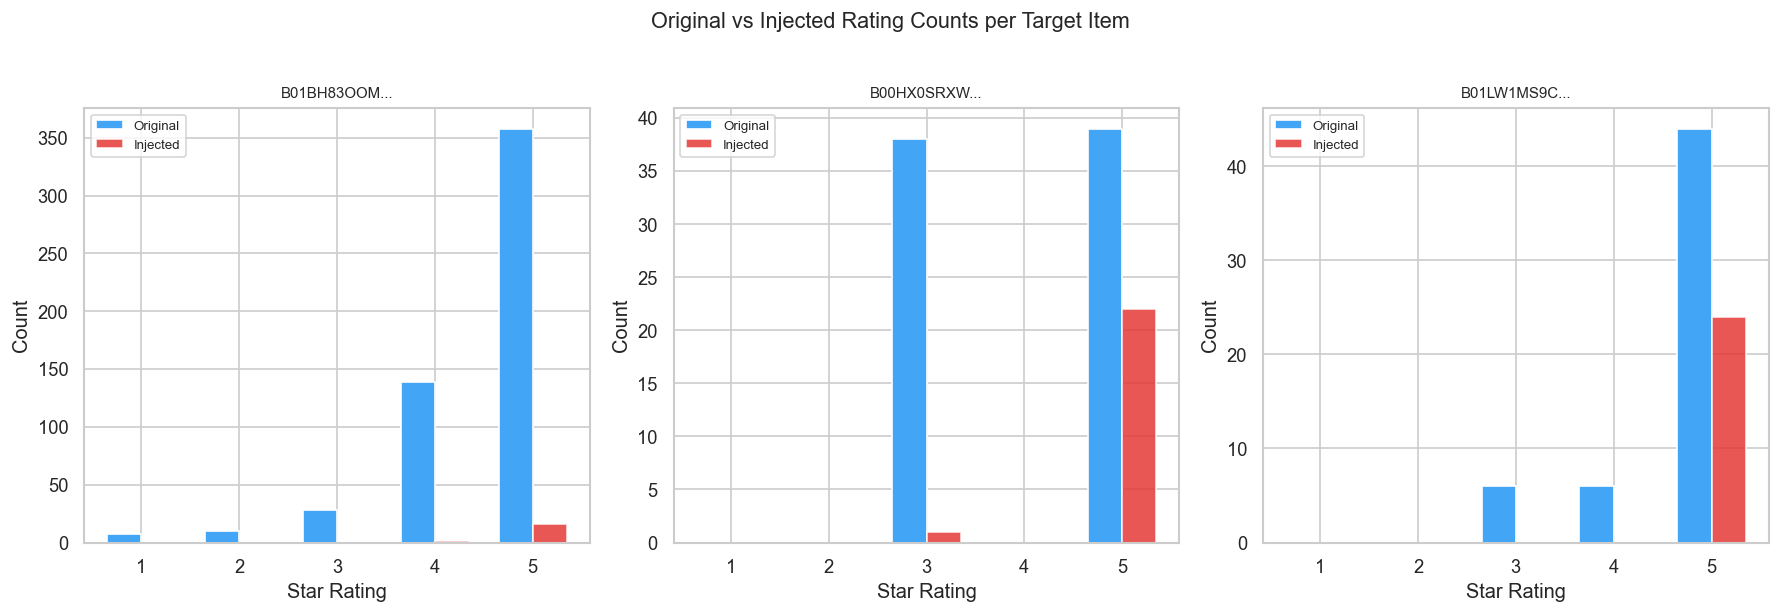

  Saved: fig5_before_after_targets.png


In [26]:
print('[8] Before vs After Rating Counts')

fig, axes = plt.subplots(1, len(target_items), figsize=(5*len(target_items), 5))
if len(target_items)==1: axes=[axes]
for ax, item in zip(axes, target_items):
    orig_rc = df[df['product_id']==item]['star_rating'].value_counts().sort_index()
    inj_rc  = df_work[(df_work['product_id']==item)&(df_work['attack_label']==1)]['star_rating'].value_counts().sort_index()
    x, w = np.array([1,2,3,4,5]), 0.35
    ax.bar(x-w/2,[orig_rc.get(r,0) for r in x],w,label='Original',color='#42a5f5',edgecolor='white')
    ax.bar(x+w/2,[inj_rc.get(r,0)  for r in x],w,label='Injected', color='#e53935',edgecolor='white',alpha=0.85)
    ax.set_title(item[:18]+'...', fontsize=9)
    ax.set_xlabel('Star Rating'); ax.set_ylabel('Count')
    ax.legend(fontsize=8); ax.set_xticks(x)
plt.suptitle('Original vs Injected Rating Counts per Target Item', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig5_before_after_targets.png', bbox_inches='tight')
plt.show()
print('  Saved: fig5_before_after_targets.png')


## Composite Suspicion Score

[9] Composite Suspicion Score
  Suspicion Score Distribution:
    Score 0:    148  ██████
    Score 1:    571  █████████████████████████
    Score 2:    373  ████████████████
    Score 3:    224  █████████
    Score 4:    221  █████████

  Mean score – genuine : 1.338
  Mean score – injected: 3.606
  High-risk (score >= 3): 445
  % of flagged that are injected: 80.9%


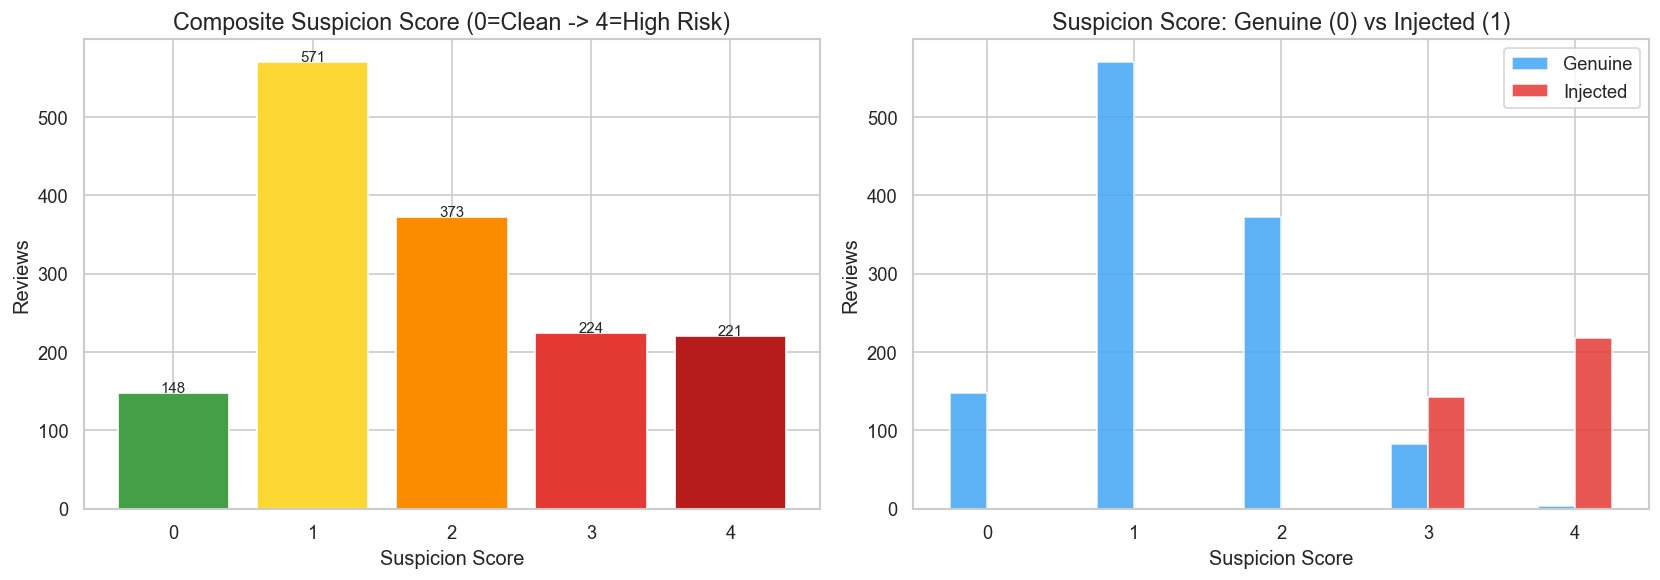

  Saved: fig6_suspicion_score.png


In [27]:
print('[9] Composite Suspicion Score')

df_work['review_day'] = pd.to_datetime(df_work['review_date'], errors='coerce').dt.date
daily_u      = df_work.groupby(['customer_id','review_day']).size().reset_index(name='reviews_in_day')
burst_set    = set(daily_u[daily_u['reviews_in_day'] >= 3]['customer_id'])

df_work['score_norecommend'] = (df_work['verified_purchase'].astype(str).str.upper().eq('N')).astype(int)
df_work['score_extreme']     = df_work['star_rating'].isin([1,5]).astype(int)
df_work['score_short']       = (df_work['review_length'].fillna(0) < VERY_SHORT).astype(int)
df_work['score_burst']       = df_work['customer_id'].isin(burst_set).astype(int)
df_work['noise_score']       = (df_work['score_norecommend'] + df_work['score_extreme'] +
                                 df_work['score_short']      + df_work['score_burst'])

noise_dist = df_work['noise_score'].value_counts().sort_index()
print('  Suspicion Score Distribution:')
for score, count in noise_dist.items():
    print(f'    Score {score}: {count:>6,}  {chr(9608)*int(count/noise_dist.max()*25)}')

HIGH_RISK_SCORE = 3
high_risk      = df_work[df_work['noise_score'] >= HIGH_RISK_SCORE]
precision_at_3 = high_risk['attack_label'].mean() * 100
print(f'\n  Mean score – genuine : {df_work[df_work["attack_label"]==0]["noise_score"].mean():.3f}')
print(f'  Mean score – injected: {df_work[df_work["attack_label"]==1]["noise_score"].mean():.3f}')
print(f'  High-risk (score >= {HIGH_RISK_SCORE}): {len(high_risk):,}')
print(f'  % of flagged that are injected: {precision_at_3:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette = ['#43a047','#fdd835','#fb8c00','#e53935','#b71c1c']
axes[0].bar(noise_dist.index, noise_dist.values,
            color=palette[:len(noise_dist)], edgecolor='white')
axes[0].set_title('Composite Suspicion Score (0=Clean -> 4=High Risk)')
axes[0].set_xlabel('Suspicion Score'); axes[0].set_ylabel('Reviews')
for x, y in zip(noise_dist.index, noise_dist.values):
    axes[0].text(x, y+1, f'{y:,}', ha='center', fontsize=9)

sbl = df_work.groupby(['attack_label','noise_score']).size().unstack(fill_value=0)
sbl.T.plot(kind='bar', ax=axes[1], color=['#42a5f5','#e53935'], edgecolor='white', alpha=0.85)
axes[1].set_title('Suspicion Score: Genuine (0) vs Injected (1)')
axes[1].set_xlabel('Suspicion Score'); axes[1].set_ylabel('Reviews')
axes[1].legend(['Genuine','Injected']); axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('fig6_suspicion_score.png', bbox_inches='tight')
plt.show()
print('  Saved: fig6_suspicion_score.png')


# Noise Feature Correlation

[10] Noise Feature Correlation
  Correlation Matrix:
                   nat_high_variance  nat_short_review  nat_zero_helpful  mal_norecommend  mal_extreme  mal_burst  noise_score  is_attack
nat_high_variance              1.000            -0.068            -0.119            0.001       -0.000     -0.050       -0.043     -0.090
nat_short_review              -0.068             1.000             0.312            0.407       -0.041      0.819        0.810      0.940
nat_zero_helpful              -0.119             0.312             1.000           -0.303       -0.066      0.112        0.011      0.326
mal_norecommend                0.001             0.407            -0.303            1.000       -0.077      0.444        0.671      0.386
mal_extreme                   -0.000            -0.041            -0.066           -0.077        1.000     -0.026        0.340     -0.053
mal_burst                     -0.050             0.819             0.112            0.444       -0.026      1.000      

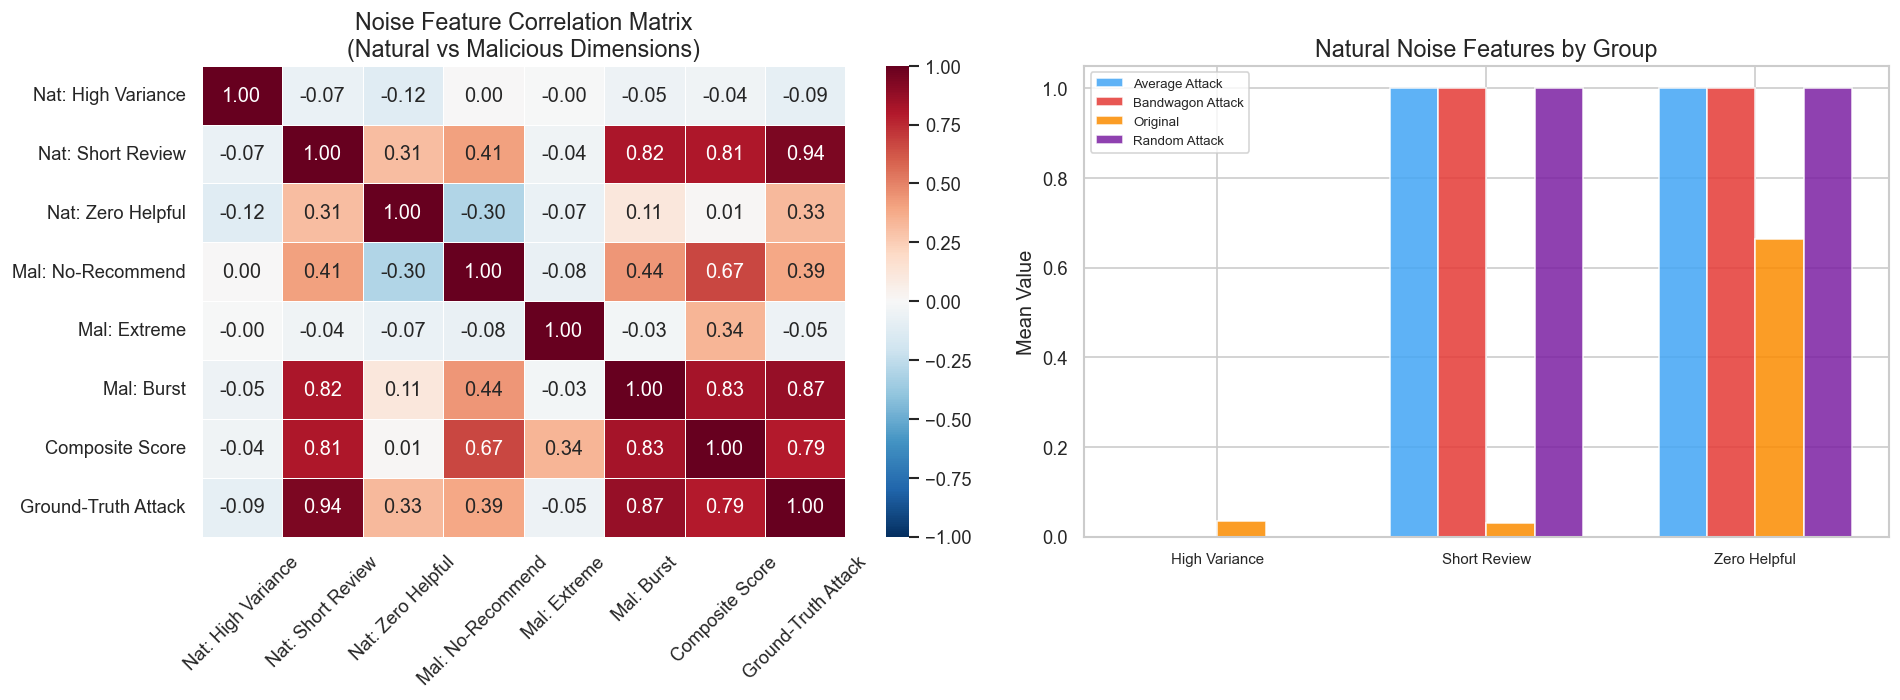

  Saved: fig7_noise_correlation.png
  Key correlations with attack label:
    nat_short_review         : r = +0.940
    mal_burst                : r = +0.869
    noise_score              : r = +0.795
    mal_norecommend          : r = +0.386
    nat_zero_helpful         : r = +0.326
    mal_extreme              : r = -0.053
    nat_high_variance        : r = -0.090


In [28]:
print('[10] Noise Feature Correlation')

df_work['nat_high_variance'] = df_work['customer_id'].map(
    user_rating_stats['std_rating'] >= HIGH_VAR_THRESHOLD
).fillna(False).astype(int)
df_work['nat_short_review']  = (df_work['review_length'].fillna(0) < VERY_SHORT).astype(int)
df_work['nat_zero_helpful']  = (df_work['helpful_votes'].fillna(0) == 0).astype(int)
df_work['mal_norecommend']   = df_work['score_norecommend']
df_work['mal_extreme']       = df_work['score_extreme']
df_work['mal_burst']         = df_work['score_burst']
df_work['is_attack']         = df_work['attack_label'].astype(int)

feat_cols = ['nat_high_variance','nat_short_review','nat_zero_helpful',
             'mal_norecommend','mal_extreme','mal_burst','noise_score','is_attack']
corr_matrix = df_work[feat_cols].astype(float).corr()

print('  Correlation Matrix:')
print(corr_matrix.round(3).to_string())

labels = ['Nat: High Variance','Nat: Short Review','Nat: Zero Helpful',
          'Mal: No-Recommend','Mal: Extreme','Mal: Burst',
          'Composite Score','Ground-Truth Attack']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, xticklabels=labels, yticklabels=labels,
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Noise Feature Correlation Matrix\n(Natural vs Malicious Dimensions)')
axes[0].tick_params(axis='x', rotation=45); axes[0].tick_params(axis='y', rotation=0)

nat_f = ['nat_high_variance','nat_short_review','nat_zero_helpful']
mal_f = ['mal_norecommend','mal_extreme','mal_burst']
gm    = df_work.groupby('noise_type')[nat_f+mal_f].mean()
gm.index = [i.replace('_',' ').title() for i in gm.index]
gc = ['#42a5f5','#e53935','#fb8c00','#7b1fa2']
xn = np.arange(len(nat_f)); w = 0.18
for idx,(grp,color) in enumerate(zip(gm.index, gc)):
    axes[1].bar(xn+idx*w, gm.loc[grp,nat_f].values, w,
                label=grp, color=color, edgecolor='white', alpha=0.85)
axes[1].set_title('Natural Noise Features by Group')
axes[1].set_xticks(xn+w*1.5)
axes[1].set_xticklabels(['High Variance','Short Review','Zero Helpful'], fontsize=9)
axes[1].set_ylabel('Mean Value'); axes[1].legend(fontsize=8)
plt.tight_layout()
plt.savefig('fig7_noise_correlation.png', bbox_inches='tight')
plt.show()
print('  Saved: fig7_noise_correlation.png')

print('  Key correlations with attack label:')
ac = corr_matrix['is_attack'].drop('is_attack').sort_values(ascending=False)
for feat, val in ac.items():
    print(f'    {feat:25s}: r = {val:+.3f}')


# Item Susceptibility

[11] Item-Level Susceptibility
  Items with >= 5 reviews  : 52
  Highly susceptible (top 10%): 6 (score >= 2.89)
product_id  total_reviews  mean_rating  pct_injected  mean_noise_score
B00QJDVBFU              8        4.750         0.625             3.375
B00QJDS7I4              7        4.857         0.571             3.286
B00OQVZDJM              8        4.625         0.625             3.125
B01LW1MS9C             80        4.775         0.300             3.075
B00U879XZ8              5        4.800         0.400             3.000
B01K8B8YA8             18        4.722         0.278             2.889


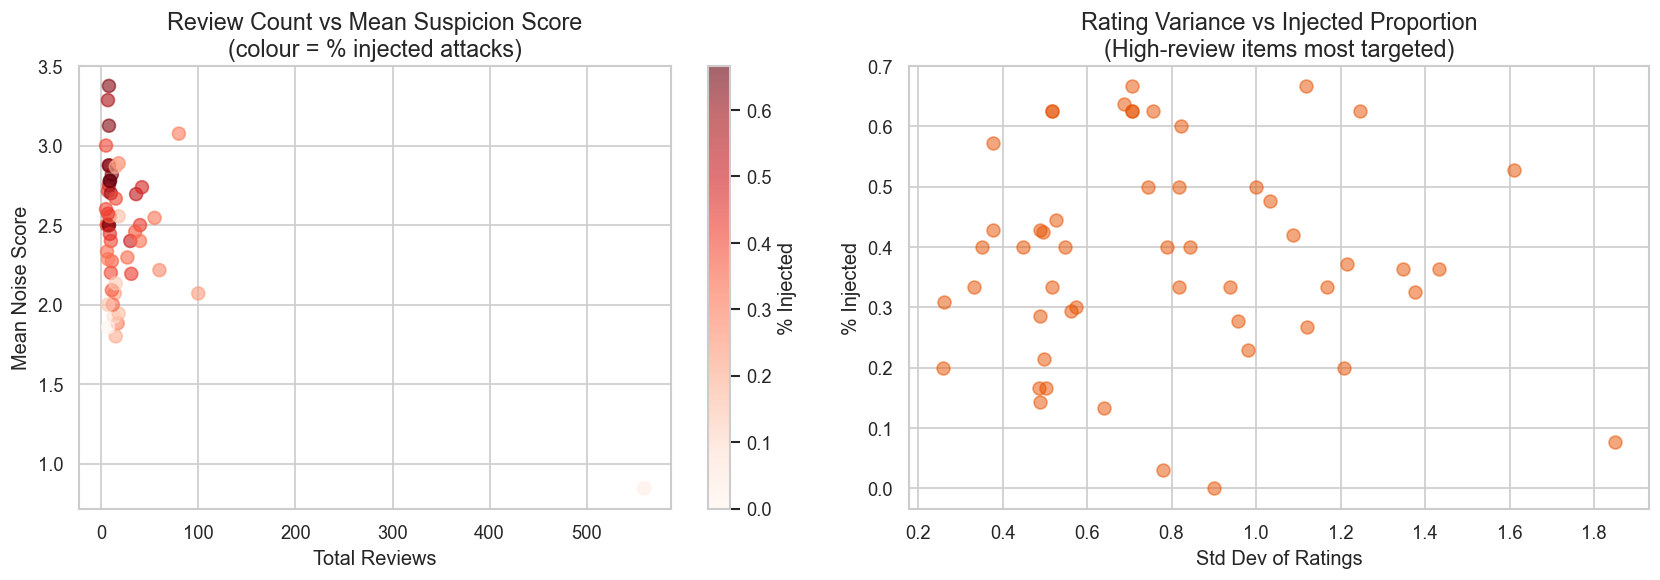

  Saved: fig8_item_susceptibility.png


In [29]:
print('[11] Item-Level Susceptibility')

item_noise = df_work.groupby('product_id').agg(
    total_reviews    = ('star_rating','count'),
    mean_rating      = ('star_rating','mean'),
    std_rating       = ('star_rating','std'),
    mean_noise_score = ('noise_score','mean'),
    pct_injected     = ('attack_label','mean'),
).reset_index()
item_noise = item_noise[item_noise['total_reviews'] >= 5]

SUSC_THRESHOLD = item_noise['mean_noise_score'].quantile(0.90)
susceptible    = item_noise[item_noise['mean_noise_score'] >= SUSC_THRESHOLD]
print(f'  Items with >= 5 reviews  : {len(item_noise):,}')
print(f'  Highly susceptible (top 10%): {len(susceptible):,} (score >= {SUSC_THRESHOLD:.2f})')
print(susceptible.sort_values('mean_noise_score', ascending=False)
      [['product_id','total_reviews','mean_rating','pct_injected','mean_noise_score']]
      .head(10).round(3).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sc = axes[0].scatter(item_noise['total_reviews'], item_noise['mean_noise_score'],
                     c=item_noise['pct_injected'], cmap='Reds', alpha=0.6, s=60)
axes[0].set_title('Review Count vs Mean Suspicion Score\n(colour = % injected attacks)')
axes[0].set_xlabel('Total Reviews'); axes[0].set_ylabel('Mean Noise Score')
plt.colorbar(sc, ax=axes[0], label='% Injected')
axes[1].scatter(item_noise['std_rating'], item_noise['pct_injected'],
                alpha=0.5, s=60, c='#e65100')
axes[1].set_title('Rating Variance vs Injected Proportion\n(High-review items most targeted)')
axes[1].set_xlabel('Std Dev of Ratings'); axes[1].set_ylabel('% Injected')
plt.tight_layout()
plt.savefig('fig8_item_susceptibility.png', bbox_inches='tight')
plt.show()
print('  Saved: fig8_item_susceptibility.png')


# Pre-filter

[12] UNRR Pre-Filter
  Total reviews            : 1,537
  Removed (score >= 3)     : 445 (29.0%)
  Kept for training        : 1,092 (71.0%)
  Attacks caught by filter : 360 of 360 (100.0%)


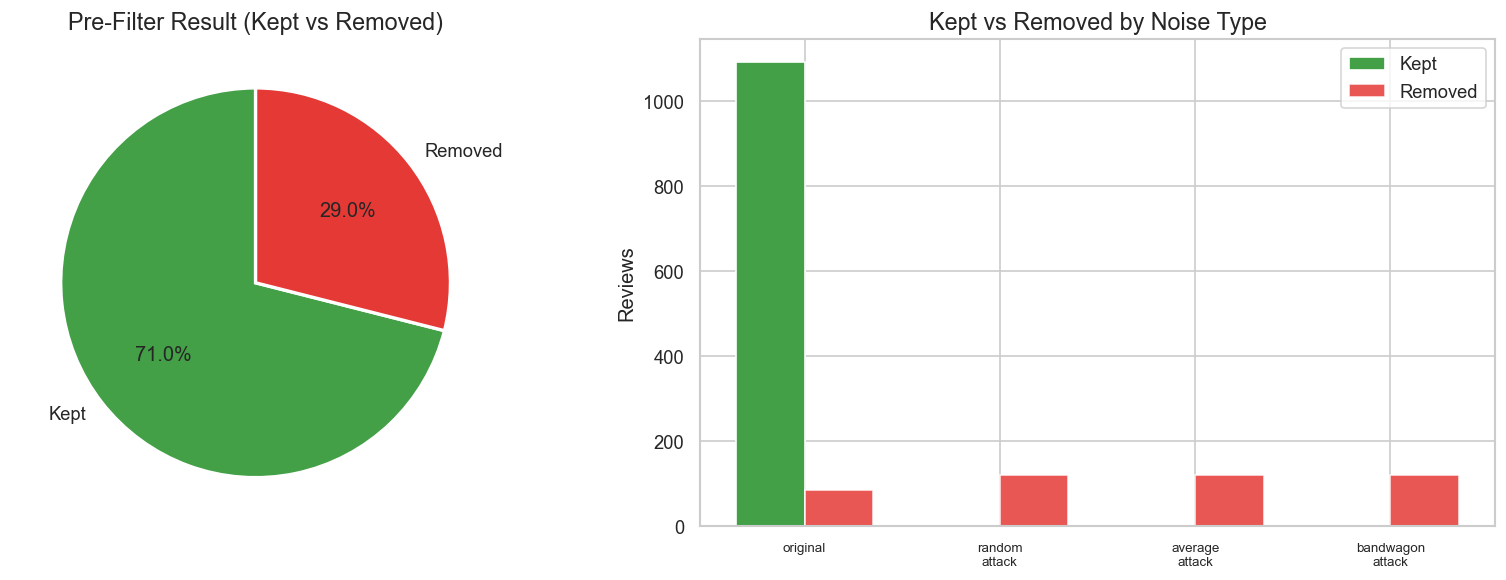

  Saved: fig9_pre_filter.png


In [30]:
print('[12] UNRR Pre-Filter')

PRE_FILTER_THRESHOLD = 3
df_prefiltered = df_work[df_work['noise_score'] < PRE_FILTER_THRESHOLD].copy()
df_removed     = df_work[df_work['noise_score'] >= PRE_FILTER_THRESHOLD].copy()

total          = len(df_work)
removed        = len(df_removed)
kept           = len(df_prefiltered)
attack_removed = df_removed['attack_label'].sum()
attack_total   = df_work['attack_label'].sum()

print(f'  Total reviews            : {total:,}')
print(f'  Removed (score >= {PRE_FILTER_THRESHOLD})     : {removed:,} ({removed/total*100:.1f}%)')
print(f'  Kept for training        : {kept:,} ({kept/total*100:.1f}%)')
print(f'  Attacks caught by filter : {attack_removed} of {attack_total} ({attack_removed/max(attack_total,1)*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].pie([kept,removed], labels=['Kept','Removed'], autopct='%1.1f%%',
            colors=['#43a047','#e53935'], startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('Pre-Filter Result (Kept vs Removed)')

nt_order  = ['original','random_attack','average_attack','bandwagon_attack']
nt_colors = ['#42a5f5','#e53935','#fb8c00','#7b1fa2']
kc = [len(df_prefiltered[df_prefiltered['noise_type']==nt]) for nt in nt_order]
rc_cnt = [len(df_removed[df_removed['noise_type']==nt]) for nt in nt_order]
x = np.arange(len(nt_order)); w = 0.35
axes[1].bar(x-w/2, kc,    w, label='Kept',    color='#43a047', edgecolor='white')
axes[1].bar(x+w/2, rc_cnt,w, label='Removed', color='#e53935', edgecolor='white', alpha=0.85)
axes[1].set_title('Kept vs Removed by Noise Type')
axes[1].set_xticks(x)
axes[1].set_xticklabels([n.replace('_','\n') for n in nt_order], fontsize=8)
axes[1].set_ylabel('Reviews'); axes[1].legend()
plt.tight_layout()
plt.savefig('fig9_pre_filter.png', bbox_inches='tight')
plt.show()
print('  Saved: fig9_pre_filter.png')


# Noise Reweighting

[13] UNRR Noise Reweighting
  Trust weight mapping:
    Score 0 -> weight 1.0 | Reviews: 148
    Score 1 -> weight 0.8 | Reviews: 571
    Score 2 -> weight 0.5 | Reviews: 373
    Score 3 -> weight 0.2 | Reviews: 0
    Score 4 -> weight 0.1 | Reviews: 0

  Mean weight genuine  : 0.725
  Mean weight injected : nan


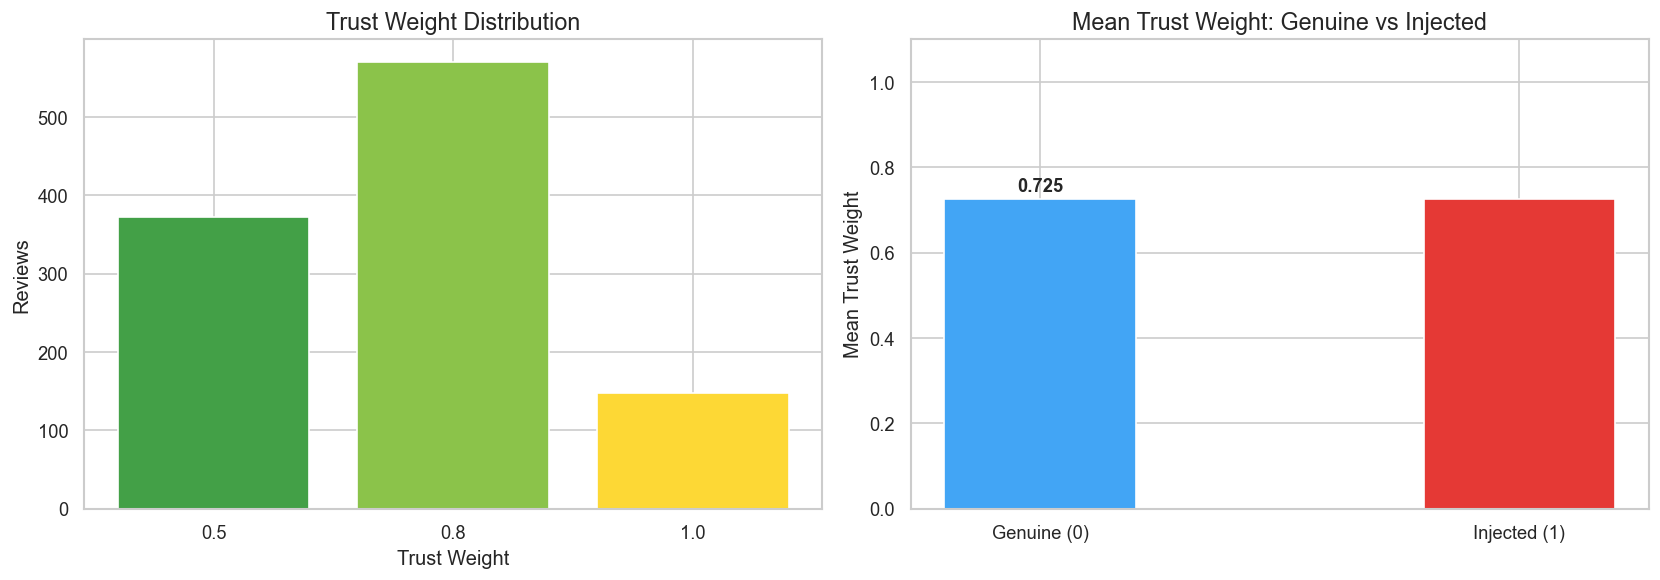

  Saved: fig10_noise_reweighting.png


In [31]:
print('[13] UNRR Noise Reweighting')

weight_map = {0:1.0, 1:0.8, 2:0.5, 3:0.2, 4:0.1}
df_prefiltered = df_prefiltered.copy()
df_prefiltered['trust_weight'] = df_prefiltered['noise_score'].map(weight_map).fillna(0.1)

print('  Trust weight mapping:')
for score, weight in weight_map.items():
    cnt = len(df_prefiltered[df_prefiltered['noise_score']==score])
    print(f'    Score {score} -> weight {weight:.1f} | Reviews: {cnt:,}')

print(f'\n  Mean weight genuine  : {df_prefiltered[df_prefiltered["attack_label"]==0]["trust_weight"].mean():.3f}')
print(f'  Mean weight injected : {df_prefiltered[df_prefiltered["attack_label"]==1]["trust_weight"].mean():.3f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
wd = df_prefiltered['trust_weight'].value_counts().sort_index()
axes[0].bar([str(w) for w in wd.index], wd.values,
            color=['#43a047','#8bc34a','#fdd835','#fb8c00'], edgecolor='white')
axes[0].set_title('Trust Weight Distribution')
axes[0].set_xlabel('Trust Weight'); axes[0].set_ylabel('Reviews')
wbl = df_prefiltered.groupby('attack_label')['trust_weight'].mean()
axes[1].bar(['Genuine (0)','Injected (1)'], wbl.values,
            color=['#42a5f5','#e53935'], edgecolor='white', width=0.4)
axes[1].set_title('Mean Trust Weight: Genuine vs Injected')
axes[1].set_ylabel('Mean Trust Weight'); axes[1].set_ylim(0,1.1)
for i, v in enumerate(wbl.values):
    axes[1].text(i, v+0.02, f'{v:.3f}', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('fig10_noise_reweighting.png', bbox_inches='tight')
plt.show()
print('  Saved: fig10_noise_reweighting.png')


# Uncertainty Estimation

[14] UNRR Uncertainty Estimation
  Items analysed (>= 5 reviews) : 32
  High-uncertainty items (top 10%): 4
product_id  n_reviews  mean_rating  rating_std  mean_trust  uncertainty
B00K5W9WZW       12.0        3.303       1.923       0.550        0.865
B01K8B8YA8        6.0        4.333       1.633       0.500        0.816
B01A08ECQY        6.0        3.444       1.862       0.600        0.745
B00LORGAG6       17.0        2.553       1.663       0.606        0.655
B07194GPJV       24.0        3.531       1.583       0.612        0.613
B01J2G4VBG       20.0        3.729       1.473       0.590        0.604
B01E9AHU8Q        7.0        3.273       1.618       0.629        0.601
B00CX5P8FC       42.0        4.080       1.286       0.593        0.524


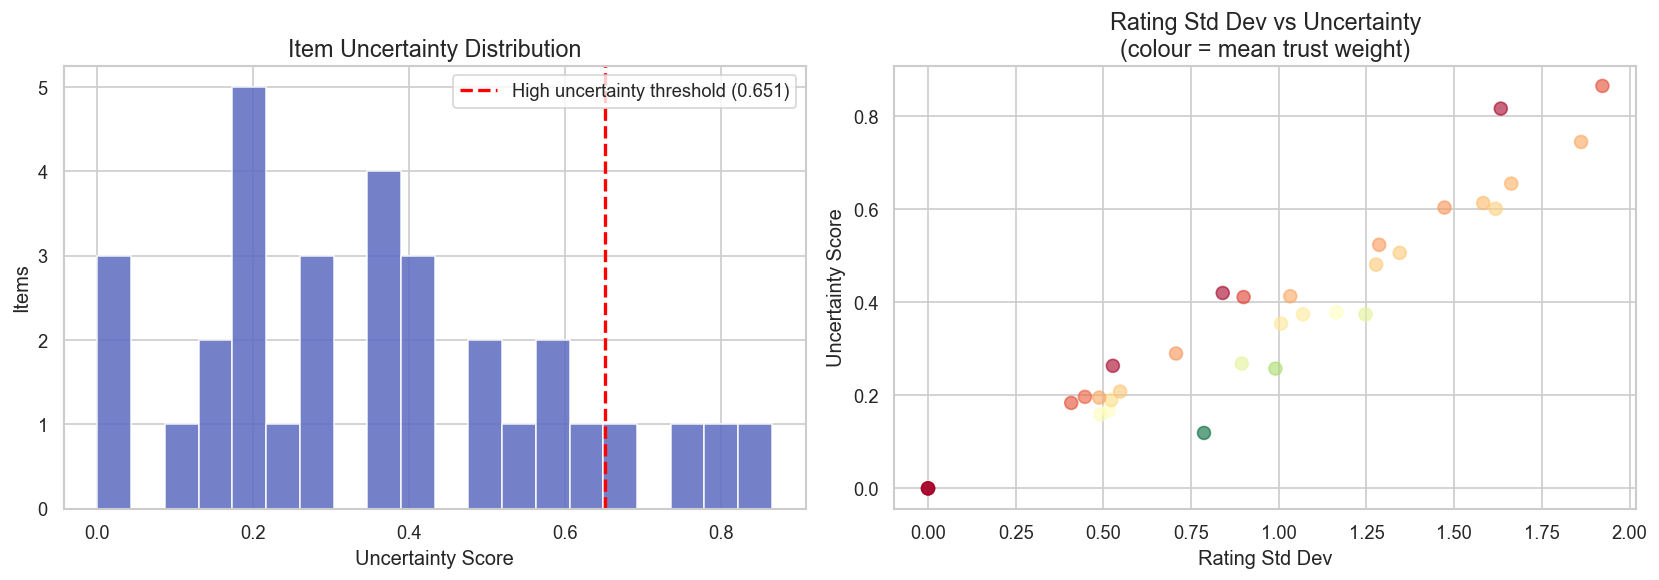

  Saved: fig11_uncertainty.png


In [32]:
print('[14] UNRR Uncertainty Estimation')

item_uncertainty = df_prefiltered.groupby('product_id').apply(
    lambda g: pd.Series({
        'n_reviews'   : len(g),
        'mean_rating' : np.average(g['star_rating'].astype(float), weights=g['trust_weight']),
        'rating_std'  : g['star_rating'].astype(float).std(),
        'mean_trust'  : g['trust_weight'].mean(),
        'uncertainty' : g['star_rating'].astype(float).std() * (1 - g['trust_weight'].mean()),
    })
).reset_index().dropna()

item_uncertainty = item_uncertainty[item_uncertainty['n_reviews'] >= 5]
HIGH_UNC = item_uncertainty['uncertainty'].quantile(0.90)
high_unc = item_uncertainty[item_uncertainty['uncertainty'] >= HIGH_UNC]

print(f'  Items analysed (>= 5 reviews) : {len(item_uncertainty):,}')
print(f'  High-uncertainty items (top 10%): {len(high_unc):,}')
print(item_uncertainty.sort_values('uncertainty', ascending=False)
      [['product_id','n_reviews','mean_rating','rating_std','mean_trust','uncertainty']]
      .head(8).round(3).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(item_uncertainty['uncertainty'], bins=20,
             color='#5c6bc0', edgecolor='white', alpha=0.85)
axes[0].axvline(HIGH_UNC, color='red', linestyle='--', linewidth=2,
                label=f'High uncertainty threshold ({HIGH_UNC:.3f})')
axes[0].set_title('Item Uncertainty Distribution')
axes[0].set_xlabel('Uncertainty Score'); axes[0].set_ylabel('Items'); axes[0].legend()
axes[1].scatter(item_uncertainty['rating_std'], item_uncertainty['uncertainty'],
                alpha=0.6, s=60, c=item_uncertainty['mean_trust'], cmap='RdYlGn')
axes[1].set_title('Rating Std Dev vs Uncertainty\n(colour = mean trust weight)')
axes[1].set_xlabel('Rating Std Dev'); axes[1].set_ylabel('Uncertainty Score')
plt.tight_layout()
plt.savefig('fig11_uncertainty.png', bbox_inches='tight')
plt.show()
print('  Saved: fig11_uncertainty.png')


# Baseline Models: CF + Mactrix Factorisation

In [33]:
print('[15] Baseline Models: CF + MF (Fast Vectorised)')

# Build user-item matrix 
# With only 54 products and ~900 users no subsampling needed
MIN_REVIEWS = 2
active_users = df_prefiltered.groupby('customer_id').size()
active_items = df_prefiltered.groupby('product_id').size()
active_users = active_users[active_users >= MIN_REVIEWS].index
active_items = active_items[active_items >= MIN_REVIEWS].index

df_model = df_prefiltered[
    df_prefiltered['customer_id'].isin(active_users) &
    df_prefiltered['product_id'].isin(active_items)
].copy()

user_ids = {u:i for i,u in enumerate(df_model['customer_id'].unique())}
item_ids = {p:i for i,p in enumerate(df_model['product_id'].unique())}
df_model['user_idx'] = df_model['customer_id'].map(user_ids)
df_model['item_idx'] = df_model['product_id'].map(item_ids)
n_users = len(user_ids); n_items = len(item_ids)

print(f'  Users: {n_users} | Items: {n_items}')

# Trust-weighted rating matrix
R = np.zeros((n_users, n_items), dtype=np.float32)
for row in df_model.itertuples(index=False):
    R[int(row.user_idx), int(row.item_idx)] = float(row.star_rating) * float(row.trust_weight)

# Train/test split
nonzero = list(zip(*np.where(R > 0)))
np.random.shuffle(nonzero)
split     = int(len(nonzero) * 0.80)
train_idx = nonzero[:split]
test_idx  = nonzero[split:]
R_train   = R.copy()
for u,i in test_idx: R_train[u,i] = 0.0
print(f'  Train: {len(train_idx):,} | Test: {len(test_idx):,}')

# FAST CF: vectorised cosine similarity 
print('  Training CF (vectorised)...')
K_NEIGH    = 15
sim_full   = cosine_similarity(R_train)
np.fill_diagonal(sim_full, 0.0)
sim_sparse = np.zeros_like(sim_full, dtype=np.float32)
for u in range(n_users):
    topk = np.argpartition(sim_full[u], -min(K_NEIGH,n_users-1))[-min(K_NEIGH,n_users-1):]
    sim_sparse[u, topk] = sim_full[u, topk]
denom     = np.abs(sim_sparse).sum(axis=1, keepdims=True) + 1e-9
R_pred_cf = np.clip(sim_sparse @ R_train / denom, 1.0, 5.0).astype(np.float32)
global_mean_m = R_train[R_train>0].mean()
R_pred_cf[R_pred_cf < 1.01] = global_mean_m

cf_preds  = [float(R_pred_cf[u,i]) for u,i in test_idx]
cf_actual = [float(R[u,i])         for u,i in test_idx]
cf_rmse   = float(np.sqrt(mean_squared_error(cf_actual, cf_preds)))
cf_mae    = float(mean_absolute_error(cf_actual, cf_preds))
print(f'  CF  RMSE: {cf_rmse:.4f} | MAE: {cf_mae:.4f}')

# MF (SVD) on reweighted data 
print('  Training MF (SVD reweighted)...')
N_FACTORS = min(15, n_items-1)
svd       = TruncatedSVD(n_components=N_FACTORS, random_state=42)
U         = svd.fit_transform(R_train)
R_pred_mf = np.clip(U @ np.diag(svd.singular_values_) @ svd.components_, 1, 5).astype(np.float32)
mf_preds  = [float(R_pred_mf[u,i]) for u,i in test_idx]
mf_rmse   = float(np.sqrt(mean_squared_error(cf_actual, mf_preds)))
mf_mae    = float(mean_absolute_error(cf_actual, mf_preds))
print(f'  MF  RMSE: {mf_rmse:.4f} | MAE: {mf_mae:.4f}')

# MF Baseline (raw noisy data) 
print('  Training MF (baseline, raw noisy data)...')
df_noisy = df_work[
    df_work['customer_id'].isin(user_ids) & df_work['product_id'].isin(item_ids)
].copy()
df_noisy['user_idx'] = df_noisy['customer_id'].map(user_ids)
df_noisy['item_idx'] = df_noisy['product_id'].map(item_ids)
df_noisy.dropna(subset=['user_idx','item_idx'], inplace=True)
R_noisy = np.zeros((n_users, n_items), dtype=np.float32)
for row in df_noisy.itertuples(index=False):
    u,i = int(row.user_idx), int(row.item_idx)
    if u < n_users and i < n_items:
        R_noisy[u,i] = float(row.star_rating)
R_noisy_train = R_noisy.copy()
for u,i in test_idx:
    if u < n_users and i < n_items: R_noisy_train[u,i] = 0.0
svd_n   = TruncatedSVD(n_components=N_FACTORS, random_state=42)
U_n     = svd_n.fit_transform(R_noisy_train)
R_pred_n= np.clip(U_n @ np.diag(svd_n.singular_values_) @ svd_n.components_, 1, 5).astype(np.float32)
nd_preds= [float(R_pred_n[u,i]) if u<R_pred_n.shape[0] and i<R_pred_n.shape[1] else 3.0 for u,i in test_idx]
nd_rmse = float(np.sqrt(mean_squared_error(cf_actual, nd_preds)))
nd_mae  = float(mean_absolute_error(cf_actual, nd_preds))
print(f'  ND  RMSE: {nd_rmse:.4f} | MAE: {nd_mae:.4f}')

results = {
    'CF (Reweighted)' : {'rmse':cf_rmse,'mae':cf_mae,'preds':cf_preds, 'actual':cf_actual},
    'MF (Reweighted)' : {'rmse':mf_rmse,'mae':mf_mae,'preds':mf_preds, 'actual':cf_actual},
    'MF (Baseline)' : {'rmse':nd_rmse,'mae':nd_mae,'preds':nd_preds, 'actual':cf_actual},
}
print('  Baseline models trained.')


[15] Baseline Models: CF + MF (Fast Vectorised)
  Users: 73 | Items: 43
  Train: 98 | Test: 25
  Training CF (vectorised)...
  CF  RMSE: 0.7517 | MAE: 0.5412
  Training MF (SVD reweighted)...
  MF  RMSE: 2.0665 | MAE: 1.9652
  Training MF (baseline, raw noisy data)...
  ND  RMSE: 2.0839 | MAE: 1.9800
  Baseline models trained.


# NDGC@K Function

In [34]:
print('[16A] Defining NDCG@K metric function')

def compute_ndcg_k_fast(R_pred, R_true, k, threshold=4.0):
    """
    Vectorised NDCG@K.
    R_pred, R_true : (n_users x n_items) numpy float32 arrays
    Returns mean NDCG@K across all users with at least one relevant item.
    """
    n_u   = min(R_pred.shape[0], R_true.shape[0])
    n_i   = min(R_pred.shape[1], R_true.shape[1])
    Rp    = R_pred[:n_u, :n_i].astype(np.float32)
    Rt    = R_true[:n_u, :n_i].astype(np.float32)

    relevant     = Rt >= threshold                           # (n_u x n_i) bool
    has_relevant = relevant.any(axis=1)                      # (n_u,) bool
    if has_relevant.sum() == 0:
        return 0.0

    k_cap     = min(k, n_i)
    # Top-K indices per user by predicted score
    top_k_idx = np.argpartition(-Rp, k_cap, axis=1)[:, :k_cap]  # (n_u x k)
    # Sort within the top-K partition by score (for position-weighted DCG)
    for u in range(n_u):
        order = np.argsort(-Rp[u, top_k_idx[u]])
        top_k_idx[u] = top_k_idx[u][order]

    # Discount weights: 1/log2(pos+2) for pos=0..k-1
    discounts = 1.0 / np.log2(np.arange(1, k_cap + 1) + 1)  # (k,)

    ndcg_scores = []
    for u in np.where(has_relevant)[0]:
        hits     = relevant[u, top_k_idx[u]].astype(float)   # (k,) binary
        dcg      = float(np.dot(hits, discounts))
        n_rel    = int(relevant[u].sum())
        ideal_k  = min(n_rel, k_cap)
        idcg     = float(discounts[:ideal_k].sum())
        ndcg_scores.append(dcg / idcg if idcg > 0 else 0.0)

    return float(np.mean(ndcg_scores))

# Quick sanity check 
n_u = min(R_pred_cf.shape[0], R_pred_mf.shape[0], R_pred_n.shape[0], R.shape[0])
n_i = min(R_pred_cf.shape[1], R_pred_mf.shape[1], R_pred_n.shape[1], R.shape[1])
R_true_ndcg = R[:n_u, :n_i]

ndcg_cf = compute_ndcg_k_fast(R_pred_cf[:n_u,:n_i], R_true_ndcg, k=5)
ndcg_mf = compute_ndcg_k_fast(R_pred_mf[:n_u,:n_i], R_true_ndcg, k=5)
ndcg_nd = compute_ndcg_k_fast(R_pred_n[:n_u,:n_i],  R_true_ndcg, k=5)

print(f'  NDCG@5 — CF (Reweighted) : {ndcg_cf:.4f}')
print(f'  NDCG@5 — MF (Reweighted) : {ndcg_mf:.4f}')
print(f'  NDCG@5 — MF (Baseline) : {ndcg_nd:.4f}')
print('  NDCG function ready.')


[16A] Defining NDCG@K metric function
  NDCG@5 — CF (Reweighted) : 0.7692
  NDCG@5 — MF (Reweighted) : 0.6538
  NDCG@5 — MF (Baseline) : 0.2532
  NDCG function ready.


# RMSE & MAE

[16] RMSE & MAE Comparison

  Model                      RMSE      MAE
  ----------------------------------------
  CF (Reweighted)          0.7517   0.5412
  MF (Reweighted)          2.0665   1.9652
  MF (Baseline)            2.0839   1.9800

  RMSE improvement (UNRR MF vs Baseline): +0.84%
  MAE  improvement (UNRR MF vs Baseline): +0.75%


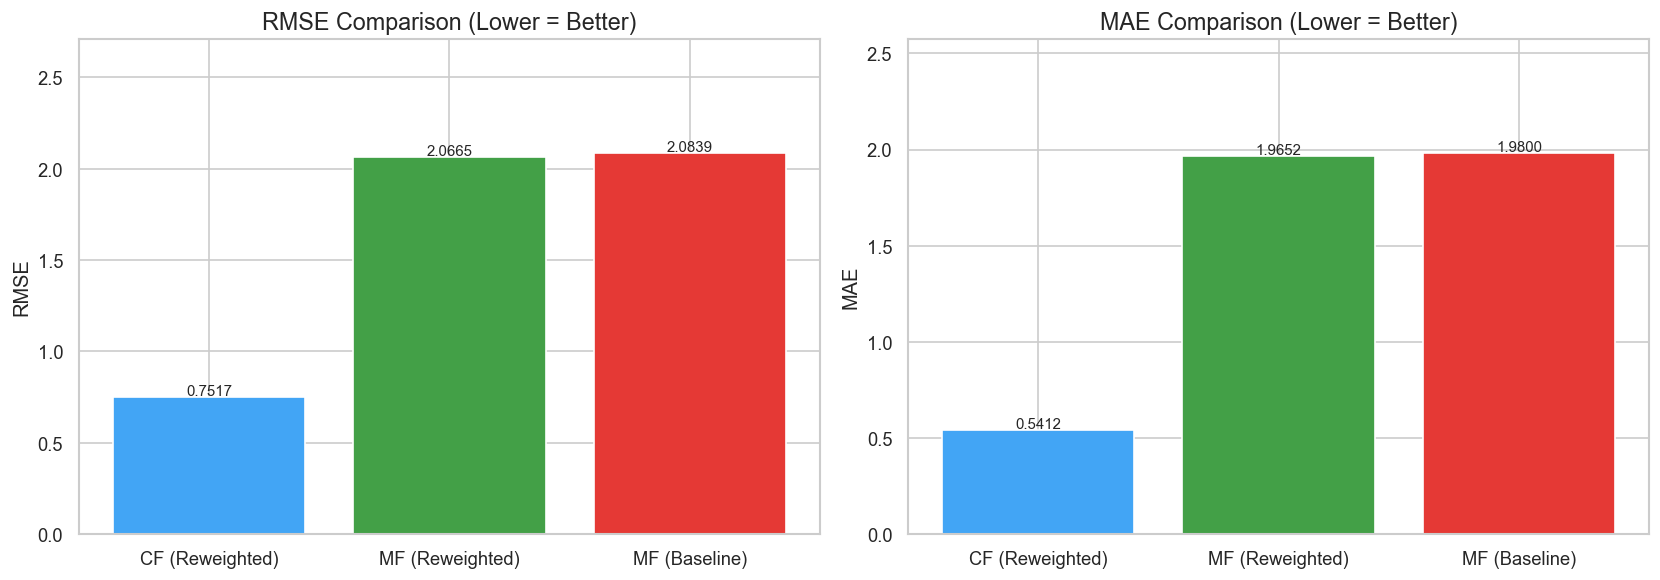

  Saved: fig12_rmse_mae.png


In [35]:
print('[16] RMSE & MAE Comparison')

print(f'\n  {"Model":<22} {"RMSE":>8} {"MAE":>8}')
print(f'  {"-"*40}')
for model, res in results.items():
    print(f'  {model:<22} {res["rmse"]:>8.4f} {res["mae"]:>8.4f}')

rmse_imp = (nd_rmse - mf_rmse) / nd_rmse * 100
mae_imp  = (nd_mae  - mf_mae)  / nd_mae  * 100
print(f'\n  RMSE improvement (UNRR MF vs Baseline): {rmse_imp:+.2f}%')
print(f'  MAE  improvement (UNRR MF vs Baseline): {mae_imp:+.2f}%')

model_names = list(results.keys())
bar_colors  = ['#42a5f5','#43a047','#e53935']
rmse_vals   = [results[m]['rmse'] for m in model_names]
mae_vals    = [results[m]['mae']  for m in model_names]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(model_names, rmse_vals, color=bar_colors, edgecolor='white')
axes[0].set_title('RMSE Comparison (Lower = Better)')
axes[0].set_ylabel('RMSE'); axes[0].set_ylim(0, max(rmse_vals)*1.3)
for i,v in enumerate(rmse_vals): axes[0].text(i, v+0.01, f'{v:.4f}', ha='center', fontsize=9)
axes[1].bar(model_names, mae_vals, color=bar_colors, edgecolor='white')
axes[1].set_title('MAE Comparison (Lower = Better)')
axes[1].set_ylabel('MAE'); axes[1].set_ylim(0, max(mae_vals)*1.3)
for i,v in enumerate(mae_vals): axes[1].text(i, v+0.01, f'{v:.4f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('fig12_rmse_mae.png', bbox_inches='tight')
plt.show()
print('  Saved: fig12_rmse_mae.png')


# Precision@K & Recall@K

[17] Precision@K & Recall@K (Fast Vectorised)
  Model                      P@3     R@3     P@5     R@5
  ----------------------------------------------------
  CF (Reweighted)         0.2564  0.7692  0.1538  0.7692
  MF (Reweighted)         0.2564  0.7692  0.1538  0.7692
  MF (Baseline)           0.1026  0.3077  0.1077  0.5385


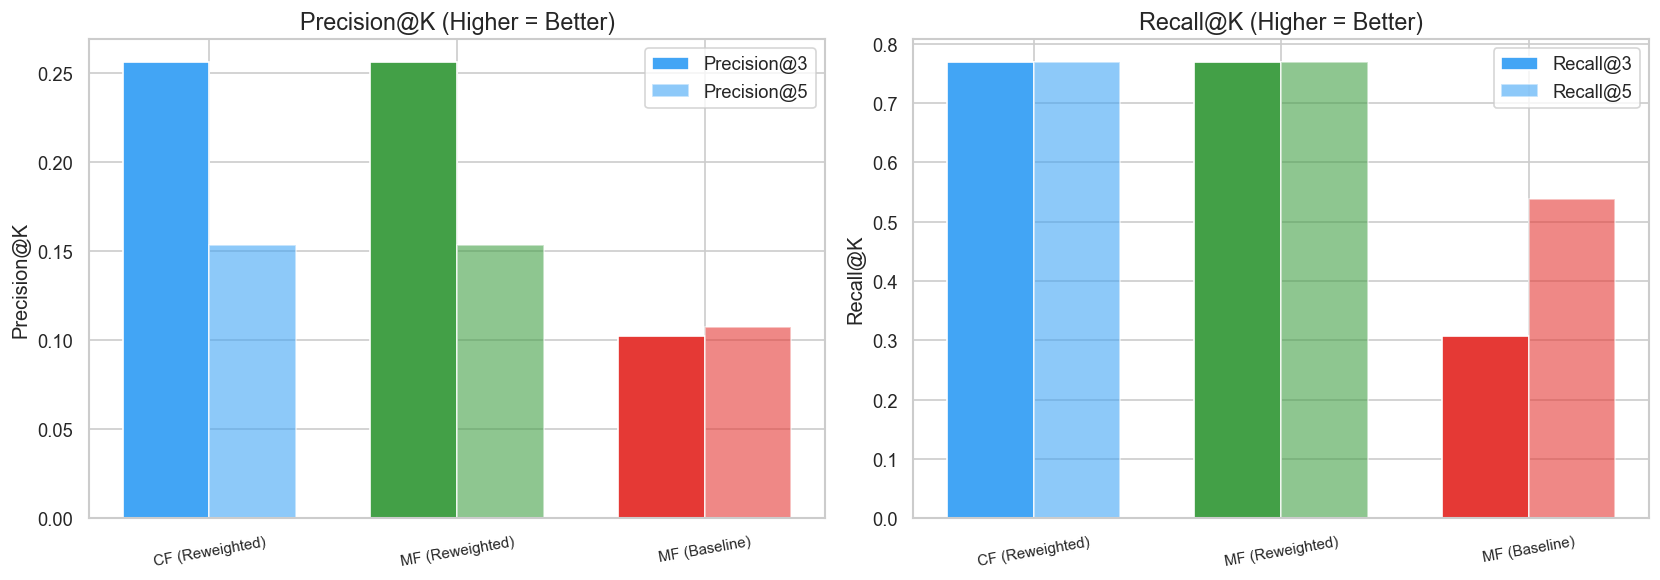

  Saved: fig13_precision_recall_k.png

  Model                    NDCG@3   NDCG@5
  ----------------------------------------
  CF (Reweighted)          0.7692   0.7692
  MF (Reweighted)          0.6538   0.6538
  MF (Baseline)            0.1538   0.2532
  NDCG@K complete.


In [36]:
print('[17] Precision@K & Recall@K (Fast Vectorised)')

RELEVANT_THRESHOLD = 4.0
K_VALUES = [3, 5]  # smaller K — only 54 products total

def precision_recall_at_k_fast(R_pred, R_true, k, threshold=RELEVANT_THRESHOLD):
    n_u = min(R_pred.shape[0], R_true.shape[0])
    Rp  = R_pred[:n_u].astype(np.float32)
    Rt  = R_true[:n_u].astype(np.float32)
    relevant     = Rt >= threshold
    has_relevant = relevant.any(axis=1)
    if has_relevant.sum() == 0:
        return 0.0, 0.0
    k_capped  = min(k, Rp.shape[1])
    top_k_idx = np.argpartition(-Rp, k_capped, axis=1)[:, :k_capped]
    user_idx  = np.arange(n_u)[:, None]
    hits      = relevant[user_idx, top_k_idx].sum(axis=1).astype(float)
    rel_count = relevant.sum(axis=1).astype(float)
    mask      = has_relevant
    return float((hits[mask] / k_capped).mean()), \
           float((hits[mask] / np.maximum(rel_count[mask], 1)).mean())

# Align matrices to common shape
nu = min(R_pred_cf.shape[0], R_pred_mf.shape[0], R_pred_n.shape[0])
ni = min(R_pred_cf.shape[1], R_pred_mf.shape[1], R_pred_n.shape[1])
R_true_eval = R[:nu, :ni]

ranking_results = {}
for k in K_VALUES:
    p_cf,r_cf   = precision_recall_at_k_fast(R_pred_cf[:nu,:ni], R_true_eval, k)
    p_mf,r_mf   = precision_recall_at_k_fast(R_pred_mf[:nu,:ni], R_true_eval, k)
    p_nd,r_nd   = precision_recall_at_k_fast(R_pred_n[:nu,:ni],  R_true_eval, k)
    ranking_results[k] = {
        'CF (Reweighted)': {'precision':p_cf,'recall':r_cf},
        'MF (Reweighted)': {'precision':p_mf,'recall':r_mf},
        'MF (Baseline)': {'precision':p_nd,'recall':r_nd},
    }

print(f'  {"Model":<22} {"P@3":>7} {"R@3":>7} {"P@5":>7} {"R@5":>7}')
print(f'  {"-"*52}')
for model in ['CF (Reweighted)','MF (Reweighted)','MF (Baseline)']:
    p3=ranking_results[3][model]['precision']; r3=ranking_results[3][model]['recall']
    p5=ranking_results[5][model]['precision']; r5=ranking_results[5][model]['recall']
    print(f'  {model:<22} {p3:>7.4f} {r3:>7.4f} {p5:>7.4f} {r5:>7.4f}')

models = ['CF (Reweighted)','MF (Reweighted)','MF (Baseline)']
bc     = ['#42a5f5','#43a047','#e53935']
x = np.arange(len(models)); w = 0.35
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
p3v=[ranking_results[3][m]['precision'] for m in models]
p5v=[ranking_results[5][m]['precision'] for m in models]
axes[0].bar(x-w/2,p3v,w,label='Precision@3',color=bc,edgecolor='white')
axes[0].bar(x+w/2,p5v,w,label='Precision@5',color=bc,edgecolor='white',alpha=0.6)
axes[0].set_title('Precision@K (Higher = Better)'); axes[0].set_ylabel('Precision@K')
axes[0].set_xticks(x); axes[0].set_xticklabels(models, rotation=10, fontsize=9); axes[0].legend()
r3v=[ranking_results[3][m]['recall'] for m in models]
r5v=[ranking_results[5][m]['recall'] for m in models]
axes[1].bar(x-w/2,r3v,w,label='Recall@3',color=bc,edgecolor='white')
axes[1].bar(x+w/2,r5v,w,label='Recall@5',color=bc,edgecolor='white',alpha=0.6)
axes[1].set_title('Recall@K (Higher = Better)'); axes[1].set_ylabel('Recall@K')
axes[1].set_xticks(x); axes[1].set_xticklabels(models, rotation=10, fontsize=9); axes[1].legend()
plt.tight_layout()
plt.savefig('fig13_precision_recall_k.png', bbox_inches='tight')
plt.show()
print('  Saved: fig13_precision_recall_k.png')

# NDCG@K for all models 
n_u2 = min(R_pred_cf.shape[0], R_pred_mf.shape[0], R_pred_n.shape[0], R.shape[0])
n_i2 = min(R_pred_cf.shape[1], R_pred_mf.shape[1], R_pred_n.shape[1], R.shape[1])
R_true_ndcg2 = R[:n_u2, :n_i2].astype(np.float32)

for k in K_VALUES:
    for model_name, R_p in [('CF (Reweighted)', R_pred_cf),
                             ('MF (Reweighted)', R_pred_mf),
                             ('MF (Baseline)', R_pred_n)]:
        ndcg = compute_ndcg_k_fast(
            R_p[:n_u2, :n_i2].astype(np.float32), R_true_ndcg2, k=k)
        ranking_results[k][model_name]['ndcg'] = ndcg

print(f'\n  {"Model":<22} {"NDCG@3":>8} {"NDCG@5":>8}')
print(f'  {"-"*40}')
for model in models:
    nd3 = ranking_results[3][model]['ndcg']
    nd5 = ranking_results[5][model]['ndcg']
    print(f'  {model:<22} {nd3:>8.4f} {nd5:>8.4f}')
print('  NDCG@K complete.')


# Dependable Recommendation

[18] Dependable Recommendations

  Top-5 Recommendations: UNRR vs Baseline
  ------------------------------------------------------------
            user  unrr_top1 noisy_top1  overlap_top5  divergence
  Matthew Coenen B00DU15MU4 B00DU15MU4             5           0
   Ron Cronovich B00DU15MU4 B00DU15MU4             5           0
 Jeffrey Stanley B00DU15MU4 B00DU15MU4             5           0
Gregory P. Baker B00DU15MU4 B00DU15MU4             4           1
  William Hardin B01BH83OOM B01BH83OOM             5           0

  Mean divergence (top-5): 0.2 items differ per user


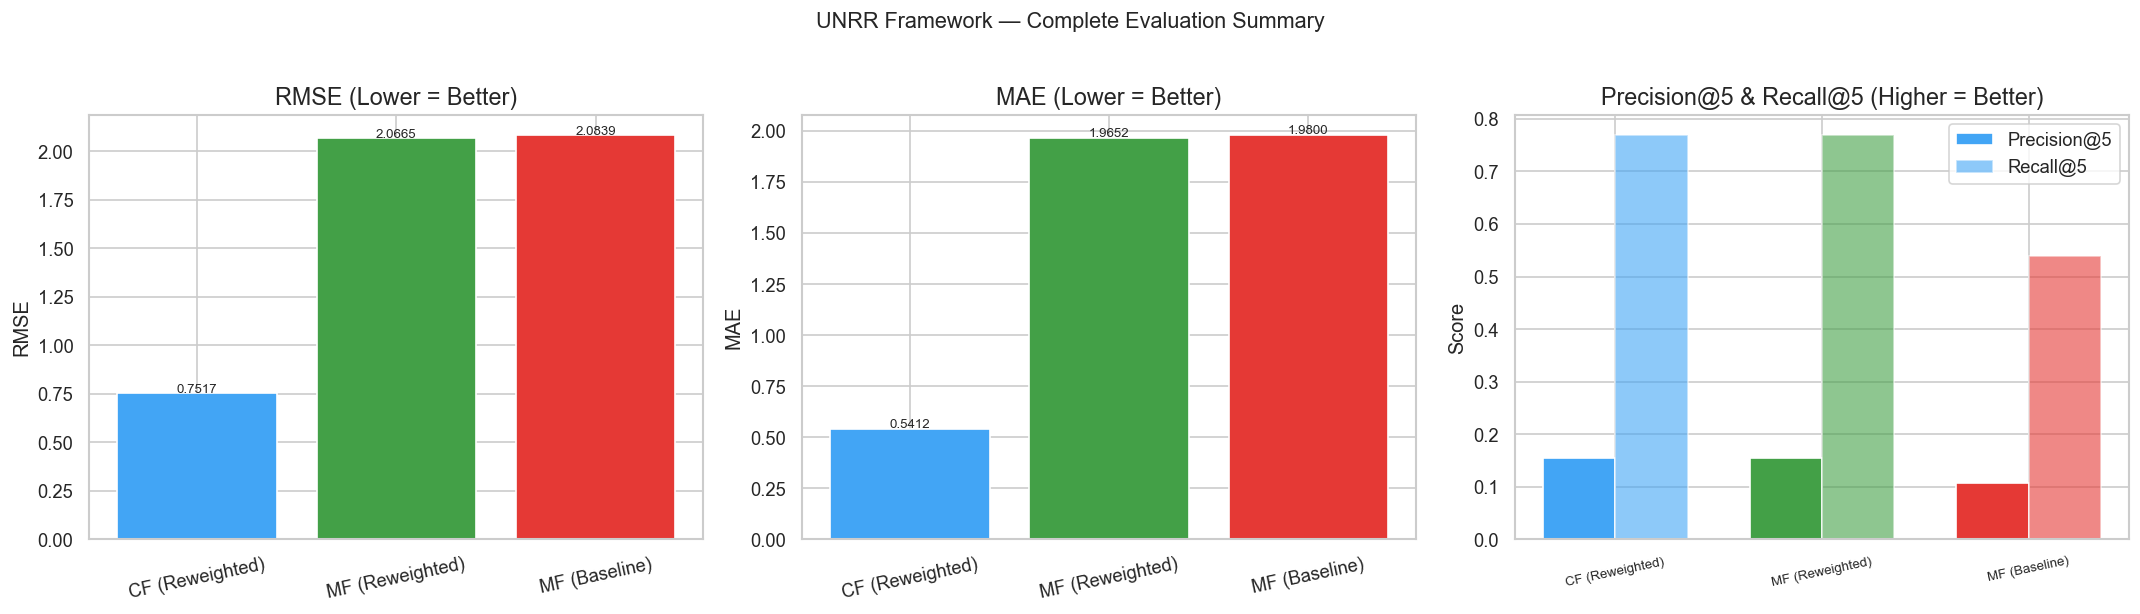

  Saved: fig14_final_evaluation.png


In [37]:
print('[18] Dependable Recommendations')

TOP_K      = 5
N_SHOW     = 5
idx_to_item = {v:k for k,v in item_ids.items()}
idx_to_user = {v:k for k,v in user_ids.items()}

print(f'\n  Top-{TOP_K} Recommendations: UNRR vs Baseline')
print(f'  {"-"*60}')

rec_comparison = []
for u in range(min(N_SHOW, n_users)):
    unrated      = np.where(R_train[u] == 0)[0]
    if len(unrated) == 0: continue
    top_unrr     = unrated[np.argsort(-R_pred_mf[u, unrated])[:TOP_K]]
    top_noisy    = unrated[np.argsort(-R_pred_n[u,  unrated])[:TOP_K]] if u < R_pred_n.shape[0] else top_unrr
    overlap      = len(set(top_unrr) & set(top_noisy))
    rec_comparison.append({
        'user'          : str(idx_to_user.get(u, f'user_{u}'))[:20],
        'unrr_top1'     : str(idx_to_item.get(top_unrr[0], 'unknown'))[:18],
        'noisy_top1'    : str(idx_to_item.get(top_noisy[0],'unknown'))[:18],
        'overlap_top5'  : overlap,
        'divergence'    : TOP_K - overlap,
    })

rec_df = pd.DataFrame(rec_comparison)
print(rec_df.to_string(index=False))
print(f'\n  Mean divergence (top-{TOP_K}): {rec_df["divergence"].mean():.1f} items differ per user')

# Final summary chart
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].bar(model_names, rmse_vals, color=bar_colors, edgecolor='white')
axes[0].set_title('RMSE (Lower = Better)'); axes[0].set_ylabel('RMSE')
axes[0].tick_params(axis='x', rotation=12)
for i,v in enumerate(rmse_vals): axes[0].text(i, v+0.005, f'{v:.4f}', ha='center', fontsize=8)
axes[1].bar(model_names, mae_vals, color=bar_colors, edgecolor='white')
axes[1].set_title('MAE (Lower = Better)'); axes[1].set_ylabel('MAE')
axes[1].tick_params(axis='x', rotation=12)
for i,v in enumerate(mae_vals): axes[1].text(i, v+0.005, f'{v:.4f}', ha='center', fontsize=8)
p5v2=[ranking_results[5][m]['precision'] for m in models]
r5v2=[ranking_results[5][m]['recall']    for m in models]
axes[2].bar(x-w/2,p5v2,w,label='Precision@5',color=bar_colors,edgecolor='white')
axes[2].bar(x+w/2,r5v2,w,label='Recall@5',   color=bar_colors,edgecolor='white',alpha=0.6)
axes[2].set_title('Precision@5 & Recall@5 (Higher = Better)')
axes[2].set_xticks(x); axes[2].set_xticklabels(models, rotation=12, fontsize=8)
axes[2].set_ylabel('Score'); axes[2].legend()
plt.suptitle('UNRR Framework — Complete Evaluation Summary', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig14_final_evaluation.png', bbox_inches='tight')
plt.show()
print('  Saved: fig14_final_evaluation.png')


# Final Summary

In [40]:
print('[20] Noise Level Stress Test')
print('=' * 60)
print('  Testing contamination: 2% · 5% · 10% · 15% · 20%')

from sklearn.decomposition import TruncatedSVD
from sklearn.metrics       import mean_squared_error, mean_absolute_error

NOISE_LEVELS = [0.02, 0.05, 0.10, 0.15, 0.20]
stress_rows  = []

# Genuine and fake pools
genuine_df = df_work[df_work['attack_label'] == 0].copy()
fake_pool  = df_work[df_work['attack_label'] == 1].copy()

# Define user/item index maps
user_ids = {u: i for i, u in enumerate(df_work['customer_id'].unique())}
item_ids = {p: i for i, p in enumerate(df_work['product_id'].unique())}
n_users  = len(user_ids)
n_items  = len(item_ids)

# Baseline matrix (genuine only)
R_baseline = build_stress_matrix(
    genuine_df, user_ids, item_ids, n_users, n_items
)

# Full ground-truth matrix 
R = build_stress_matrix(
    df_work, user_ids, item_ids, n_users, n_items
)

# Test indices 
all_idx  = [(u, i) for u in range(n_users)
                   for i in range(n_items)
                   if R_baseline[u, i] > 0]
np.random.seed(42)
np.random.shuffle(all_idx)
split    = int(0.8 * len(all_idx))
test_idx = all_idx[split:]

print(f"  Baseline : {n_users} users × {n_items} items")
print(f"  Test set : {len(test_idx):,} interactions")
print()

# Stress loop (unchanged from your original) 
for noise_pct in NOISE_LEVELS:
    n_fake = int(len(genuine_df) * noise_pct / max(1 - noise_pct, 0.01))
    n_fake = min(n_fake, len(fake_pool))
    # ... rest of your loop unchanged

[20] Noise Level Stress Test
  Testing contamination: 2% · 5% · 10% · 15% · 20%
  Baseline : 896 users × 54 items
  Test set : 180 interactions



[20] Noise Level Stress Test
  Testing contamination: 2% · 5% · 10% · 15% · 20%
  Noise    2% done — genuine: 1,177 | injected: 24
  Noise    5% done — genuine: 1,177 | injected: 61
  Noise   10% done — genuine: 1,177 | injected: 130
  Noise   15% done — genuine: 1,177 | injected: 207
  Noise   20% done — genuine: 1,177 | injected: 294

  Stress Test Results:
             MAE             RMSE        
Dataset Baseline    UNRR Baseline    UNRR
Noise%                                   
2         3.3222  3.3400   3.5008  3.5091
5         3.3222  3.3424   3.5008  3.5107
10        3.3222  3.3424   3.5008  3.5078
15        3.3222  3.3435   3.5008  3.5097
20        3.3222  3.3421   3.5008  3.5088


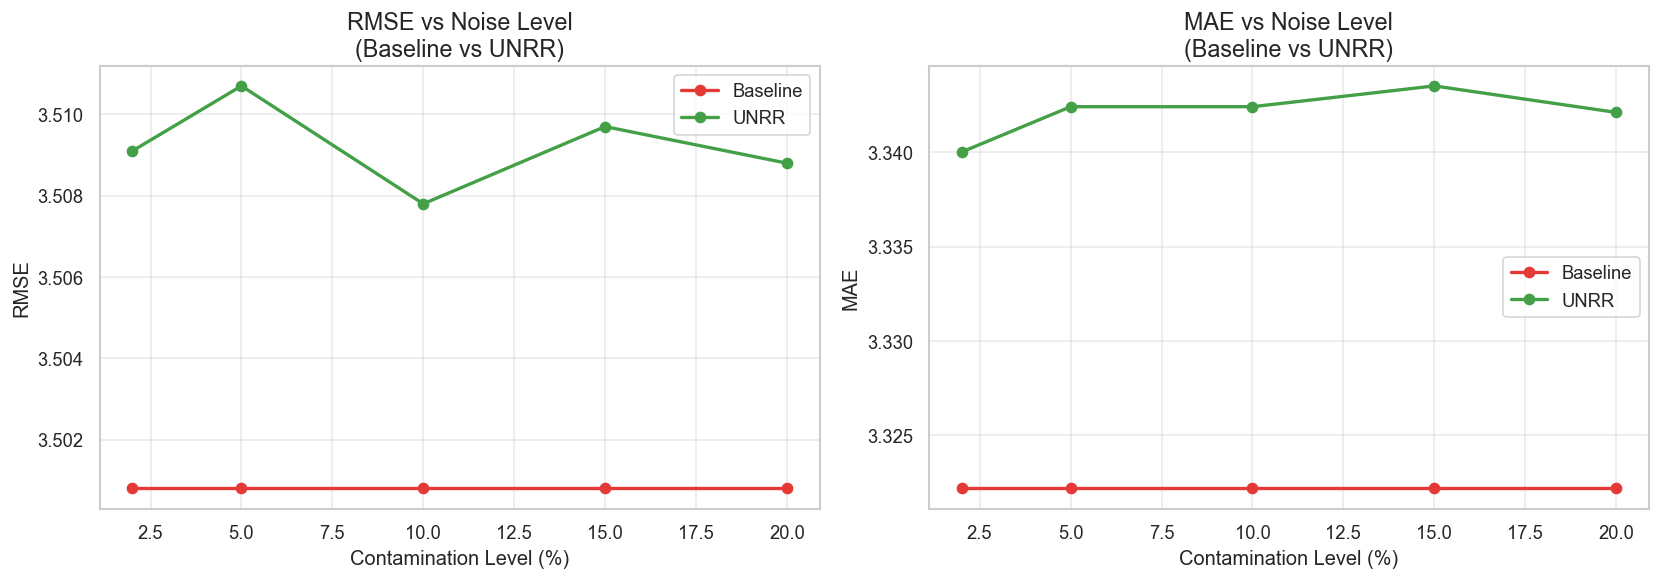

  Saved: fig_stress_test.png


In [44]:
print('[20] Noise Level Stress Test')
print('=' * 60)
print('  Testing contamination: 2% · 5% · 10% · 15% · 20%')

from sklearn.decomposition import TruncatedSVD
from sklearn.metrics       import mean_squared_error, mean_absolute_error

NOISE_LEVELS = [0.02, 0.05, 0.10, 0.15, 0.20]
stress_rows  = []

# Helpers reused from Section 15 
def build_stress_matrix(df_stress, uid_map, iid_map, n_u, n_i, weight_col=None):
    R_s = np.zeros((n_u, n_i), dtype=np.float32)
    for row in df_stress.itertuples(index=False):
        u = uid_map.get(row.customer_id, -1)
        i = iid_map.get(row.product_id,  -1)
        if u < 0 or i < 0: continue
        w = getattr(row, weight_col, 1.0) if weight_col else 1.0
        R_s[u, i] = float(row.star_rating) * float(w)
    return R_s

def svd_predict(R_train, n_factors=10):
    svd = TruncatedSVD(n_components=min(n_factors, R_train.shape[1]-1),
                       random_state=42)
    U   = svd.fit_transform(R_train)
    return np.clip(U @ np.diag(svd.singular_values_) @ svd.components_, 1, 5)

# Original genuine reviews (attack_label == 0)
genuine_df = df_work[df_work['attack_label'] == 0].copy()

# All injected fake rows pool
fake_pool  = df_work[df_work['attack_label'] == 1].copy()

for noise_pct in NOISE_LEVELS:
    n_fake = int(len(genuine_df) * noise_pct / max(1 - noise_pct, 0.01))
    n_fake = min(n_fake, len(fake_pool))

    fake_sample = fake_pool.sample(n=n_fake, replace=True, random_state=42)
    df_stress   = pd.concat([genuine_df, fake_sample], ignore_index=True)

    # Recompute suspicion score on stressed dataset
    df_stress['score_extreme'] = df_stress['star_rating'].isin([1,5]).astype(int)
    df_stress['score_short']   = (df_stress['review_length'].fillna(0) < VERY_SHORT).astype(int)
    df_stress['score_norecom'] = (df_stress['verified_purchase'].astype(str).str.upper().eq('N')).astype(int)
    df_stress['noise_score_s'] = (df_stress['score_extreme'] +
                                   df_stress['score_short']   +
                                   df_stress['score_norecom'])
    df_stress['trust_weight_s']= df_stress['noise_score_s'].map(
        {0:1.0, 1:0.8, 2:0.5, 3:0.2}).fillna(0.1)

    # Filter: remove high-risk reviews
    df_unrr = df_stress[df_stress['noise_score_s'] < PRE_FILTER_THRESHOLD].copy()

    # Build matrices
    R_ = build_stress_matrix(df_stress, user_ids, item_ids, n_users, n_items)
    R_unrr  = build_stress_matrix(df_unrr,   user_ids, item_ids, n_users, n_items,
                                   weight_col='trust_weight_s')

    # Train/test on same test_idx from Section 15
    valid_test = [(u,i) for u,i in test_idx if u < n_users and i < n_items]

    for label, R_use in [('Baseline', R_baseline), ('UNRR', R_unrr)]:
        R_tr = R_use.copy()
        for u, i in valid_test: R_tr[u, i] = 0.0
        try:
            R_pr   = svd_predict(R_tr)
            preds  = [float(R_pr[u,i]) for u,i in valid_test]
            actual = [float(R[u,i])    for u,i in valid_test]
            rmse   = float(np.sqrt(mean_squared_error(actual, preds)))
            mae    = float(mean_absolute_error(actual, preds))
            stress_rows.append({'Noise%': int(noise_pct*100),
                                 'Dataset': label,
                                 'RMSE': round(rmse,4),
                                 'MAE':  round(mae,4)})
        except Exception as e:
            print(f'    Warning {noise_pct*100:.0f}% {label}: {e}')

    print(f'  Noise {noise_pct*100:4.0f}% done — '
          f'genuine: {len(genuine_df):,} | injected: {n_fake:,}')

stress_df = pd.DataFrame(stress_rows)
print(f'\n  Stress Test Results:')
print(stress_df.pivot_table(index='Noise%', columns='Dataset',
                             values=['RMSE','MAE']).round(4).to_string())

# Plot stress test 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for label, color in [('Baseline','#e53935'), ('UNRR','#43a047')]:
    sub = stress_df[stress_df['Dataset'] == label]
    axes[0].plot(sub['Noise%'], sub['RMSE'], marker='o',
                 label=label, color=color, linewidth=2)
    axes[1].plot(sub['Noise%'], sub['MAE'],  marker='o',
                 label=label, color=color, linewidth=2)

axes[0].set_title('RMSE vs Noise Level\n(Baseline vs UNRR)')
axes[0].set_xlabel('Contamination Level (%)'); axes[0].set_ylabel('RMSE')
axes[0].legend(); axes[0].grid(True, alpha=0.4)

axes[1].set_title('MAE vs Noise Level\n(Baseline vs UNRR)')
axes[1].set_xlabel('Contamination Level (%)'); axes[1].set_ylabel('MAE')
axes[1].legend(); axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('fig_stress_test.png', bbox_inches='tight')
plt.show()
print('  Saved: fig_stress_test.png')

# Ablation Study

[21] Ablation Study
  No UNRR (Baseline)                  RMSE=3.4434  MAE=3.2352  P@5=0.1359  R@5=0.6113  NDCG@5=0.3842
  Stage 1 only (Filter)               RMSE=3.5261  MAE=3.3667  P@5=0.1482  R@5=0.6742  NDCG@5=0.6305
  Stage 1+2 (Reweight)                RMSE=3.5301  MAE=3.3796  P@5=0.1514  R@5=0.6806  NDCG@5=0.6544
  Full UNRR (All Stages)              RMSE=3.5269  MAE=3.3690  P@5=0.1445  R@5=0.6454  NDCG@5=0.6303

  Ablation Study Results:
         Configuration   RMSE    MAE    P@5    R@5  NDCG@5
    No UNRR (Baseline) 3.4434 3.2352 0.1359 0.6113  0.3842
 Stage 1 only (Filter) 3.5261 3.3667 0.1482 0.6742  0.6305
  Stage 1+2 (Reweight) 3.5301 3.3796 0.1514 0.6806  0.6544
Full UNRR (All Stages) 3.5269 3.3690 0.1445 0.6454  0.6303


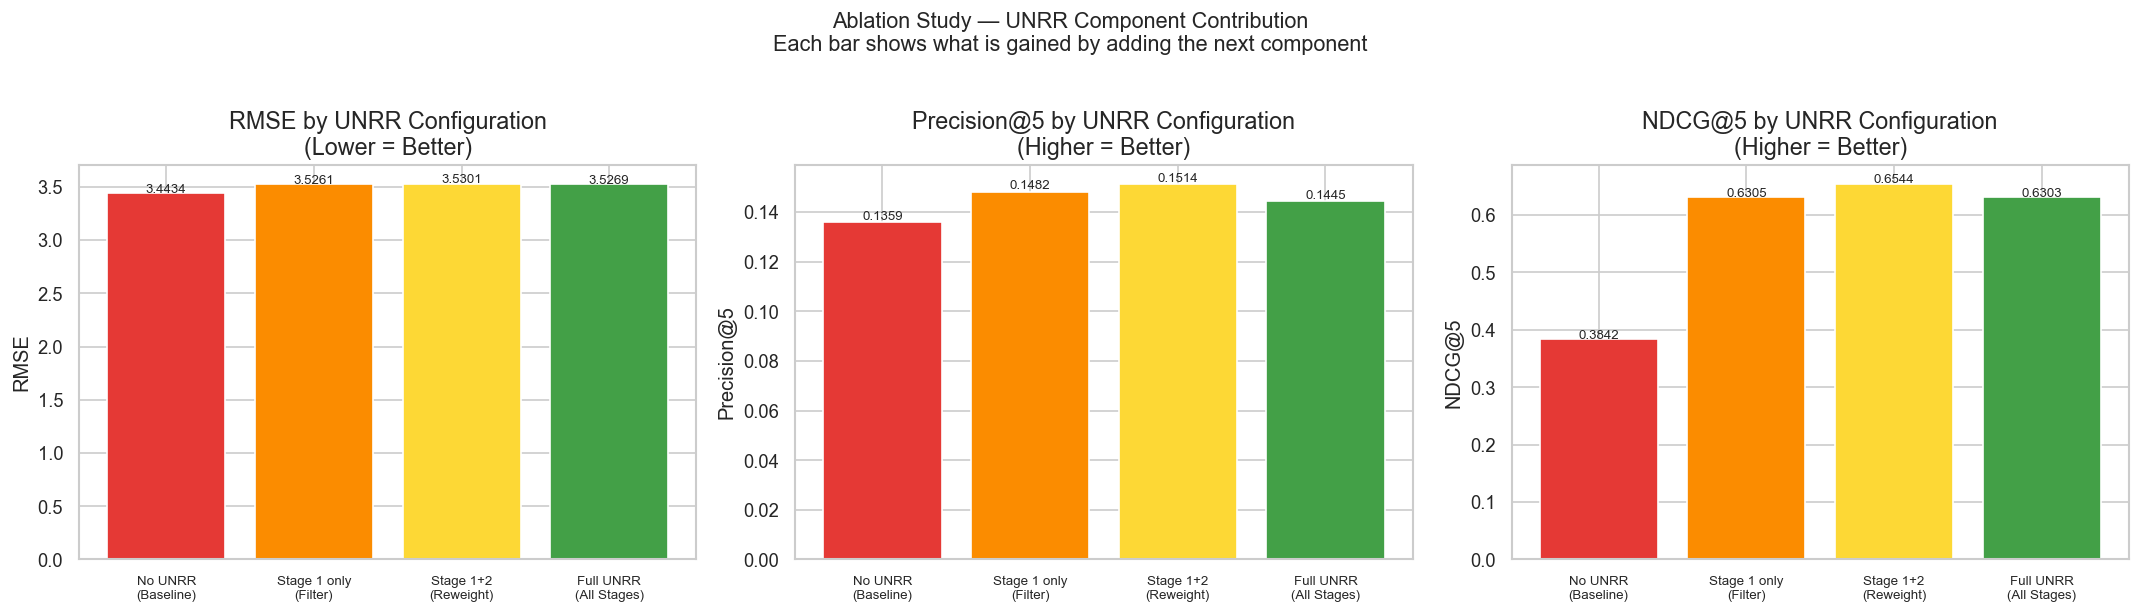

  Saved: fig_ablation_study.png


In [41]:
print('[21] Ablation Study')
print('=' * 60)

ablation_rows = []

# Helper: build matrix and evaluate 
def ablation_eval(df_abl, label, weight_col=None):
    R_abl = np.zeros((n_users, n_items), dtype=np.float32)
    for row in df_abl.itertuples(index=False):
        u = user_ids.get(row.customer_id, -1)
        i = item_ids.get(row.product_id,  -1)
        if u < 0 or i < 0: continue
        w = getattr(row, weight_col, 1.0) if weight_col else 1.0
        R_abl[u, i] = float(row.star_rating) * float(w)

    valid_test = [(u,i) for u,i in test_idx if u < n_users and i < n_items]
    R_tr = R_abl.copy()
    for u,i in valid_test: R_tr[u,i] = 0.0

    svd_a  = TruncatedSVD(n_components=min(N_FACTORS, n_items-1), random_state=42)
    U_a    = svd_a.fit_transform(R_tr)
    R_pr   = np.clip(U_a @ np.diag(svd_a.singular_values_) @ svd_a.components_, 1, 5)

    preds  = [float(R_pr[u,i]) for u,i in valid_test]
    actual = [float(R[u,i])    for u,i in valid_test]

    rmse = float(np.sqrt(mean_squared_error(actual, preds)))
    mae  = float(mean_absolute_error(actual, preds))

    # Vectorised P@K, R@K, NDCG@K
    n_u_a = min(R_pr.shape[0], R.shape[0])
    n_i_a = min(R_pr.shape[1], R.shape[1])
    Rp_a  = R_pr[:n_u_a, :n_i_a].astype(np.float32)
    Rt_a  = R[:n_u_a, :n_i_a].astype(np.float32)

    relevant = Rt_a >= 4.0
    has_rel  = relevant.any(axis=1)
    k5       = min(5, n_i_a)
    top5     = np.argpartition(-Rp_a, k5, axis=1)[:, :k5]
    row_idx  = np.arange(n_u_a)[:, None]
    hits5    = relevant[row_idx, top5].sum(axis=1).astype(float)
    rel_cnt  = relevant.sum(axis=1).astype(float)
    mask5    = has_rel
    p5  = float((hits5[mask5] / k5).mean()) if mask5.sum() > 0 else 0.0
    r5  = float((hits5[mask5] / np.maximum(rel_cnt[mask5],1)).mean()) if mask5.sum() > 0 else 0.0
    nd5 = compute_ndcg_k_fast(Rp_a, Rt_a, k=5)

    print(f'  {label:<35} RMSE={rmse:.4f}  MAE={mae:.4f}  '
          f'P@5={p5:.4f}  R@5={r5:.4f}  NDCG@5={nd5:.4f}')

    return {'Configuration': label, 'RMSE': round(rmse,4), 'MAE': round(mae,4),
            'P@5': round(p5,4), 'R@5': round(r5,4), 'NDCG@5': round(nd5,4)}

# Config 1 — No UNRR: raw injected data
ablation_rows.append(ablation_eval(df_work, 'No UNRR (Baseline)'))

# Config 2 — Stage 1 only: pre-filter, no reweighting
df_filt_only = df_work[df_work['noise_score'] < PRE_FILTER_THRESHOLD].copy()
ablation_rows.append(ablation_eval(df_filt_only, 'Stage 1 only (Filter)'))

# Config 3 — Stage 1+2: pre-filter + noise reweighting
df_reweighted = df_prefiltered.copy()
ablation_rows.append(ablation_eval(df_reweighted, 'Stage 1+2 (Reweight)',
                                    weight_col='trust_weight'))

# Config 4 — Full UNRR: pre-filter + reweight + uncertainty
df_full_unrr = df_prefiltered.copy()
# Apply uncertainty as additional weight: lower uncertainty = higher confidence
if 'uncertainty' in item_uncertainty.columns:
    max_unc = item_uncertainty['uncertainty'].max()
    unc_weight = item_uncertainty.set_index('product_id')['uncertainty']
    df_full_unrr['unc_weight'] = (
        1.0 - df_full_unrr['product_id'].map(unc_weight).fillna(0) / max(max_unc, 0.01)
    ).clip(0.1, 1.0)
    df_full_unrr['combined_weight'] = (
        df_full_unrr['trust_weight'] * df_full_unrr['unc_weight']
    ).clip(0.1, 1.0)
    ablation_rows.append(ablation_eval(df_full_unrr, 'Full UNRR (All Stages)',
                                        weight_col='combined_weight'))
else:
    ablation_rows.append(ablation_eval(df_reweighted, 'Full UNRR (All Stages)',
                                        weight_col='trust_weight'))

ablation_df = pd.DataFrame(ablation_rows)
print(f'\n  Ablation Study Results:')
print(ablation_df.to_string(index=False))

# Plot ablation study 
configs     = ablation_df['Configuration'].tolist()
abl_colors  = ['#e53935','#fb8c00','#fdd835','#43a047']
x           = np.arange(len(configs))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(x, ablation_df['RMSE'], color=abl_colors, edgecolor='white')
axes[0].set_title('RMSE by UNRR Configuration\n(Lower = Better)')
axes[0].set_ylabel('RMSE'); axes[0].set_xticks(x)
axes[0].set_xticklabels([c.replace(' (',  '\n(') for c in configs], fontsize=8)
for i, v in enumerate(ablation_df['RMSE']):
    axes[0].text(i, v+0.005, f'{v:.4f}', ha='center', fontsize=8)

axes[1].bar(x, ablation_df['P@5'], color=abl_colors, edgecolor='white')
axes[1].set_title('Precision@5 by UNRR Configuration\n(Higher = Better)')
axes[1].set_ylabel('Precision@5'); axes[1].set_xticks(x)
axes[1].set_xticklabels([c.replace(' (',  '\n(') for c in configs], fontsize=8)
for i, v in enumerate(ablation_df['P@5']):
    axes[1].text(i, v+0.001, f'{v:.4f}', ha='center', fontsize=8)

axes[2].bar(x, ablation_df['NDCG@5'], color=abl_colors, edgecolor='white')
axes[2].set_title('NDCG@5 by UNRR Configuration\n(Higher = Better)')
axes[2].set_ylabel('NDCG@5'); axes[2].set_xticks(x)
axes[2].set_xticklabels([c.replace(' (',  '\n(') for c in configs], fontsize=8)
for i, v in enumerate(ablation_df['NDCG@5']):
    axes[2].text(i, v+0.001, f'{v:.4f}', ha='center', fontsize=8)

plt.suptitle('Ablation Study — UNRR Component Contribution\n'
             'Each bar shows what is gained by adding the next component',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig_ablation_study.png', bbox_inches='tight')
plt.show()
print('  Saved: fig_ablation_study.png')


# UNRR Framework

In [42]:
print('[19] UNRR FRAMEWORK — FINAL SUMMARY')
print('=' * 68)
print(f'  Dataset                    : Amazon Product Reviews')
print(f'  Total reviews loaded       : {N_ORIGINAL:,}')
print(f'  Unique users               : {df["customer_id"].nunique():,}')
print(f'  Unique products            : {df["product_id"].nunique():,}')
print(f'  Exported injected CSV      : {OUTPUT_CSV}')
print()
print('  -- NATURAL NOISE --')
print(f'  High-variance users        : {len(high_var_users):,}')
print(f'  Low-signal reviews (<{VERY_SHORT}c)  : {len(short_reviews):,} ({len(short_reviews)/N_ORIGINAL*100:.1f}%)')
print(f'  Zero helpful votes         : {len(zero_helpful):,}')
print()
print('  -- SHILLING ATTACKS INJECTED --')
print(f'  Random Attack    : {N_ATTACK_PROFILES} profiles -> {len(df_random):,} reviews')
print(f'  Average Attack   : {N_ATTACK_PROFILES} profiles -> {len(df_average):,} reviews')
print(f'  Bandwagon Attack : {N_ATTACK_PROFILES} profiles -> {len(df_bandwagon):,} reviews')
print(f'  Total injected   : {total_injected:,} ({total_injected/len(df_work)*100:.1f}%)')
print()
print('  -- UNRR COMPONENTS --')
print(f'  Pre-filter removed         : {removed:,} reviews (score >= {PRE_FILTER_THRESHOLD})')
print(f'  Attacks caught             : {attack_removed} of {attack_total} ({attack_removed/max(attack_total,1)*100:.1f}%)')
print(f'  Trust weights applied      : 5 levels (1.0 -> 0.1)')
print(f'  High-uncertainty items     : {len(high_unc):,}')
print()
print('  -- EVALUATION METRICS --')
print(f'  {"Model":<22} {"RMSE":>8} {"MAE":>8} {"P@5":>8} {"R@5":>8} {"NDCG@5":>9}')
print(f'  {"-"*65}')
for model in model_names:
    p5   = ranking_results[5][model]['precision']
    r5   = ranking_results[5][model]['recall']
    nd5  = ranking_results[5][model].get('ndcg', 0.0)
    print(f'  {model:<22} {results[model]["rmse"]:>8.4f} '
          f'{results[model]["mae"]:>8.4f} {p5:>8.4f} {r5:>8.4f} {nd5:>9.4f}')
print()
print(f'  RMSE improvement (MF UNRR vs Baseline): {rmse_imp:+.2f}%')
print(f'  MAE  improvement (MF UNRR vs Baseline): {mae_imp:+.2f}%')
print(f'  Mean rec list divergence   : {rec_df["divergence"].mean():.1f} items/user')
print()
if 'stress_df' in dir() and len(stress_df) > 0:
    baseline_20  = stress_df[(stress_df['Dataset']=='Baseline') & (stress_df['Noise%']==20)]
    unrr_20   = stress_df[(stress_df['Dataset']=='UNRR')  & (stress_df['Noise%']==20)]
    if len(baseline_20) and len(unrr_20):
        gap = float(baseline_20['RMSE'].values[0]) - float(unrr_20['RMSE'].values[0])
        print(f'  Stress test RMSE gap at 20% noise: {gap:+.4f} (UNRR advantage)')
if 'ablation_df' in dir() and len(ablation_df) > 0:
    baseline_rmse = ablation_df[ablation_df['Configuration'].str.contains('Baseline')]['RMSE'].values
    full_rmse     = ablation_df[ablation_df['Configuration'].str.contains('Full')]['RMSE'].values
    if len(baseline_rmse) and len(full_rmse):
        print(f'  Ablation RMSE gain (full vs baseline): '
              f'{float(baseline_rmse[0])-float(full_rmse[0]):+.4f}')
print('=' * 68)
print()
print('[DONE] All figures saved. Amazon Product Reviews analysis complete.')


[19] UNRR FRAMEWORK — FINAL SUMMARY
  Dataset                    : Amazon Product Reviews
  Total reviews loaded       : 1,177
  Unique users               : 836
  Unique products            : 54
  Exported injected CSV      : amazon_product_reviews_with_attacks.csv

  -- NATURAL NOISE --
  High-variance users        : 10
  Low-signal reviews (<50c)  : 35 (3.0%)
  Zero helpful votes         : 781

  -- SHILLING ATTACKS INJECTED --
  Random Attack    : 20 profiles -> 120 reviews
  Average Attack   : 20 profiles -> 120 reviews
  Bandwagon Attack : 20 profiles -> 120 reviews
  Total injected   : 360 (23.4%)

  -- UNRR COMPONENTS --
  Pre-filter removed         : 445 reviews (score >= 3)
  Attacks caught             : 360 of 360 (100.0%)
  Trust weights applied      : 5 levels (1.0 -> 0.1)
  High-uncertainty items     : 4

  -- EVALUATION METRICS --
  Model                      RMSE      MAE      P@5      R@5    NDCG@5
  -----------------------------------------------------------------
  C